## Load results
Allow loading results from multiple folders

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

def load_result_dicts(dirs, whitelist=None, blacklist=None, equivalence_dict=None, include_trivia=True, replace_all_dashes=False):
    """
    Combine results from multiple sweep directories
    """

    all_dicts = {}
    for dir_path in dirs:
        print(f"Loading results from {dir_path}")
        # get names of all children of dir_path, which are format *dict.pkl
        all_files = os.listdir(dir_path)
        dict_files = [f for f in all_files if f.endswith('dict.pkl')]
        for f in dict_files:
            shortened_name = f.split('_dict.pkl')[0]
            if shortened_name not in all_dicts:
                all_dicts[shortened_name] = {}

            d = pickle.load(open(os.path.join(dir_path, f), 'rb')) # d is a dictionary of {model_name: model_results}
            print(f"Loading from {dir_path}/{f}")

            if "trivia" in shortened_name.lower() and include_trivia:
                # fix trivia dictionary
                # nested dictionary with "hard" and "easy" keys, {model_name: trivia_score} as values
                # need change to model_name on outside, {"hard": score, "easy": score} on inside
                new_d = {}
                for difficulty in d:
                    for model_name in d[difficulty]:
                        if model_name not in new_d:
                            new_d[model_name] = {}
                        new_d[model_name][difficulty] = d[difficulty][model_name]
                d = new_d

            if shortened_name in all_dicts:
                # update the all_dicts[f] with all the keys in d
                # for k in d:
                #     all_dicts[shortened_name][k] = d[k]
                for k in d:
                    model_name = k
                    if equivalence_dict is not None and k in equivalence_dict:
                        model_name = equivalence_dict[k]
                    if replace_all_dashes:
                        model_name = model_name.replace("-", "_")

                    if whitelist is not None and model_name not in whitelist:
                        continue
                    if blacklist is not None and model_name in blacklist:
                        continue
                    if model_name in all_dicts[shortened_name]:
                        all_dicts[shortened_name][model_name].update(d[k])
                    else:
                        all_dicts[shortened_name][model_name] = d[k]
                # all_dicts[shortened_name].update(d)
            else:
                # add it to the all_dicts
                # all_dicts[shortened_name] = d
                for k in d:
                    model_name = k
                    if equivalence_dict is not None and k in equivalence_dict:
                        model_name = equivalence_dict[k]
                    if replace_all_dashes:
                        model_name = model_name.replace("-", "_")
                    if whitelist is not None and model_name not in whitelist:
                        continue
                    if blacklist is not None and model_name in blacklist:
                        continue
                    all_dicts[shortened_name][model_name] = d[k]
                
    return all_dicts

## fix mistakes in naming

In [2]:
with open("results/pca-wikitext-layers8_16-final_paper/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
with open("results/pca-wikitext-layers8_16-final_paper/full_capability_dict.pkl", "rb") as f:
    capability_dict = pickle.load(f)
# familiarity_dict.keys()
capability_map_dict = {capability_name: familiarity_name for capability_name, familiarity_name in zip(capability_dict.keys(), familiarity_dict.keys())}
familiarity_map_dict = {familiarity_name: capability_name for capability_name, familiarity_name in zip(capability_dict.keys(), familiarity_dict.keys())}
familiarity_map_dict

{'PhillipGuo/hp-lat-llama-PCA-epsilon0.5-pgd_layer8_16-def_layer8-wikitext-60': 'PCA_Eps0.5_layer8_16_sftwikitext_60',
 'PhillipGuo/hp-lat-llama-PCA-epsilon1.0-pgd_layer8_16-def_layer8-wikitext-60': 'PCA_Eps1.0_layer8_16_sftwikitext_60',
 'PhillipGuo/hp-lat-llama-PCA-epsilon1.5-pgd_layer8_16-def_layer8-wikitext-60': 'PCA_Eps1.5_layer8_16_sftwikitext_60',
 'PhillipGuo/hp-lat-llama-PCA-epsilon3.0-pgd_layer8_16-def_layer8-wikitext-60': 'PCA_Eps3.0_layer8_16_sftwikitext_60',
 'PhillipGuo/hp-lat-llama-PCA-epsilon6.0-pgd_layer8_16-def_layer8-wikitext-60': 'PCA_Eps6.0_layer8_16_sftwikitext_60',
 'PhillipGuo/hp-lat-llama-PCA-epsilon0.5-pgd_layer8_16-def_layer8-wikitext-61': 'PCA_Eps0.5_layer8_16_sftwikitext_61',
 'PhillipGuo/hp-lat-llama-PCA-epsilon1.0-pgd_layer8_16-def_layer8-wikitext-61': 'PCA_Eps1.0_layer8_16_sftwikitext_61',
 'PhillipGuo/hp-lat-llama-PCA-epsilon1.5-pgd_layer8_16-def_layer8-wikitext-61': 'PCA_Eps1.5_layer8_16_sftwikitext_61',
 'PhillipGuo/hp-lat-llama-PCA-epsilon3.0-pgd_lay

In [3]:
new_results_dir = "results/pca-wikitext-layers8_16-final_paper"
replace_all_dashes = False
all_dicts = load_result_dicts([new_results_dir], equivalence_dict=familiarity_map_dict, replace_all_dashes=replace_all_dashes)
new_models = list(all_dicts['familiarity'].keys())

Loading results from results/pca-wikitext-layers8_16-final_paper
Loading from results/pca-wikitext-layers8_16-final_paper/summary_style_dict.pkl
Loading from results/pca-wikitext-layers8_16-final_paper/familiarity_dict.pkl
Loading from results/pca-wikitext-layers8_16-final_paper/full_capability_dict.pkl
Loading from results/pca-wikitext-layers8_16-final_paper/spanish_familiarity_dict.pkl
Loading from results/pca-wikitext-layers8_16-final_paper/text_lines_dict.pkl
Loading from results/pca-wikitext-layers8_16-final_paper/dan_adversarial_dict.pkl


In [4]:
# all_dicts = load_result_dicts(["results/llama-lat-less-noise", "results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless"], whitelist=["WHP", "WHP_Replication", "WHP_All_Coefs", 'PCA_L10_Eps0.1', 'PCA_L15_Eps0.1', 'PCA_L20_Eps0.1', 'PCA_L10_Eps1.0', 'PCA_L15_Eps1.0', 'PCA_L20_Eps1.0', 'PCA_L10_Eps10.0', 'PCA_L15_Eps10.0', 'PCA_L20_Eps10.0', "WHP_Original"], equivalence_dict={"WHP": "WHP_Original"})
# all_dicts = load_result_dicts(["results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless", "results/pca-harmless-multi-run"], whitelist=['WHP_Replication_1', 'WHP_All_Coefs_1', 'PCA_L15_Def15_Eps10_1', 'PCA_L15_Def0_Eps10_1', 'PCA_L10_Def10_Eps0.1_1', 'PCA_L10_Def0_Eps0.1_1', 'WHP_Replication_2', 'WHP_All_Coefs_2', 'PCA_L15_Def15_Eps10_2', 'PCA_L15_Def0_Eps10_2', 'PCA_L10_Def10_Eps0.1_2', 'PCA_L10_Def0_Eps0.1_2', 'WHP_Replication_3', 'WHP_All_Coefs_3', 'PCA_L15_Def15_Eps10_3', 'PCA_L15_Def0_Eps10_3', 'PCA_L10_Def10_Eps0.1_3', 'PCA_L10_Def0_Eps0.1_3', 'LLaMA', 'WHP_Original'], equivalence_dict={"WHP": "WHP_Original"})
# all_dicts = load_result_dicts([
#     "results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless", "results/pca-harmless-multi-run",
# "results/pca-harmless-multi-run", "results/pca-ultrachat-baselines-run", "results/pca-ultrachat-multi-run", "results/pca-ultrachat-towards_only-multi-run"
# ], whitelist=['WHP_Replication_4', 'WHP_All_Coefs_4', 'Eps0.5_4', 'Eps1.5_4', 'Eps3.0_4', 'Eps6.0_4', 'WHP_Replication_5', 'WHP_All_Coefs_5', 'Eps0.5_5', 'Eps1.5_5', 'Eps3.0_5', 'Eps6.0_5', 'WHP_Replication_6', 'WHP_All_Coefs_6', 'Eps0.5_6', 'Eps1.5_6', 'Eps3.0_6', 'Eps6.0_6', 'Eps0.5_TowardsOnly_4', 'Eps1.5_TowardsOnly_4', 'Eps3.0_TowardsOnly_4', 'Eps6.0_TowardsOnly_4', 'Eps0.5_TowardsOnly_5', 'Eps1.5_TowardsOnly_5', 'Eps3.0_TowardsOnly_5', 'Eps6.0_TowardsOnly_5', 'Eps0.5_TowardsOnly_6', 'Eps1.5_TowardsOnly_6', 'Eps3.0_TowardsOnly_6', 'Eps6.0_TowardsOnly_6','LLaMA', 'WHP_Original'], equivalence_dict={"WHP": "WHP_Original"})


# all_dicts = load_result_dicts([
#     "results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless", "results/pca-harmless-multi-run",
# "results/pca-harmless-multi-run", "results/pca-ultrachat-baselines-run", "results/pca-ultrachat-multi-run", "results/pca_actual-ultrachat-multi-run"], whitelist=['WHP_Replication_4', 'WHP_All_Coefs_4', 'WHP_Replication_5', 'WHP_All_Coefs_5', 'WHP_Replication_6', 'WHP_All_Coefs_6', 'PCA_Eps0.5_layer8_16_24_30_7', 'PCA_Eps1.5_layer8_16_24_30_7', 'PCA_Eps3.0_layer8_16_24_30_7', 'PCA_Eps6.0_layer8_16_24_30_7', 'PCA_Eps0.5_layer16_24_30_7', 'PCA_Eps1.5_layer16_24_30_7', 'PCA_Eps3.0_layer16_24_30_7', 'PCA_Eps6.0_layer16_24_30_7', 'LLaMA', 'WHP_Original'], equivalence_dict={"WHP": "WHP_Original"})

all_dicts = load_result_dicts([
    "results/llama-lat-less-noise-2", "results/pca-ultrachat-final-sweep-sft_type=harmless", "results/pca-harmless-multi-run",
"results/pca-harmless-multi-run", "results/pca-ultrachat-baselines-run", "results/pca-ultrachat-multi-run", "results/pile_pca-wikitext", new_results_dir], whitelist=[
    # 'WHP_Replication_4', 'WHP_All_Coefs_4', 'WHP_Replication_5', 'WHP_All_Coefs_5', 'WHP_Replication_6', 'WHP_All_Coefs_6', 
    'LLaMA', 'WHP_Original'] + new_models, equivalence_dict={"WHP": "WHP_Original"} | familiarity_map_dict, replace_all_dashes=replace_all_dashes)



Loading results from results/llama-lat-less-noise-2
Loading from results/llama-lat-less-noise-2/capability_dict.pkl
Loading from results/llama-lat-less-noise-2/full_capability_dict.pkl
Loading from results/llama-lat-less-noise-2/spanish_familiarity_dict.pkl
Loading from results/llama-lat-less-noise-2/summary_style_dict.pkl
Loading from results/llama-lat-less-noise-2/trivia_dict.pkl
Loading from results/llama-lat-less-noise-2/dan_adversarial_dict.pkl
Loading from results/llama-lat-less-noise-2/familiarity_dict.pkl
Loading results from results/pca-ultrachat-final-sweep-sft_type=harmless
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/familiarity_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/trivia_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/summary_style_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmless/dan_adversarial_dict.pkl
Loading from results/pca-ultrachat-final-sweep-sft_type=harmles

In [5]:
print(all_dicts['familiarity'].keys())
print(all_dicts['trivia'].keys())
print(all_dicts['full_capability'].keys())
print(all_dicts['summary_style'].keys())
print(all_dicts['spanish_familiarity'].keys())
print(all_dicts['dan_adversarial'].keys())
print(all_dicts['text_lines'].keys())

dict_keys(['LLaMA', 'WHP_Original', 'PCA_Eps0.5_layer8_16_sftwikitext_60', 'PCA_Eps1.0_layer8_16_sftwikitext_60', 'PCA_Eps1.5_layer8_16_sftwikitext_60', 'PCA_Eps3.0_layer8_16_sftwikitext_60', 'PCA_Eps6.0_layer8_16_sftwikitext_60', 'PCA_Eps0.5_layer8_16_sftwikitext_61', 'PCA_Eps1.0_layer8_16_sftwikitext_61', 'PCA_Eps1.5_layer8_16_sftwikitext_61', 'PCA_Eps3.0_layer8_16_sftwikitext_61', 'PCA_Eps6.0_layer8_16_sftwikitext_61', 'PCA_Eps0.5_layer8_16_sftwikitext_62', 'PCA_Eps1.0_layer8_16_sftwikitext_62', 'PCA_Eps1.5_layer8_16_sftwikitext_62', 'PCA_Eps3.0_layer8_16_sftwikitext_62', 'PCA_Eps6.0_layer8_16_sftwikitext_62', 'PCA_Eps0.5_layer8_16_sftwikitext_63', 'PCA_Eps1.0_layer8_16_sftwikitext_63', 'PCA_Eps1.5_layer8_16_sftwikitext_63', 'PCA_Eps3.0_layer8_16_sftwikitext_63', 'PCA_Eps6.0_layer8_16_sftwikitext_63', 'PCA_Eps0.5_layer8_16_sftwikitext_64', 'PCA_Eps1.0_layer8_16_sftwikitext_64', 'PCA_Eps1.5_layer8_16_sftwikitext_64', 'PCA_Eps3.0_layer8_16_sftwikitext_64', 'PCA_Eps6.0_layer8_16_sftwik

# Analyzing LAT familiarity + Adversarial Testing results

In [6]:
def get_familiarity_score(dict):
    try:
        overall_dict = {}
        for key in dict:
            total_responses = dict[key].get(0, 0) + dict[key].get(1, 0) + dict[key].get(2, 0) + dict[key].get(3, 0)
            total_correct = dict[key].get(2, 0) / 5 + dict[key].get(3, 0)
            overall_dict[key] = total_correct / total_responses
        return overall_dict
    except: # not nested
        for key in dict:
            total_responses = dict.get(0, 0) + dict.get(1, 0) + dict.get(2, 0) + dict.get(3, 0)
            total_correct = dict.get(2, 0) / 5 + dict.get(3, 0)
            return total_correct / total_responses


In [7]:
new_models

['PCA_Eps0.5_layer8_16_sftwikitext_60',
 'PCA_Eps1.0_layer8_16_sftwikitext_60',
 'PCA_Eps1.5_layer8_16_sftwikitext_60',
 'PCA_Eps3.0_layer8_16_sftwikitext_60',
 'PCA_Eps6.0_layer8_16_sftwikitext_60',
 'PCA_Eps0.5_layer8_16_sftwikitext_61',
 'PCA_Eps1.0_layer8_16_sftwikitext_61',
 'PCA_Eps1.5_layer8_16_sftwikitext_61',
 'PCA_Eps3.0_layer8_16_sftwikitext_61',
 'PCA_Eps6.0_layer8_16_sftwikitext_61',
 'PCA_Eps0.5_layer8_16_sftwikitext_62',
 'PCA_Eps1.0_layer8_16_sftwikitext_62',
 'PCA_Eps1.5_layer8_16_sftwikitext_62',
 'PCA_Eps3.0_layer8_16_sftwikitext_62',
 'PCA_Eps6.0_layer8_16_sftwikitext_62',
 'PCA_Eps0.5_layer8_16_sftwikitext_63',
 'PCA_Eps1.0_layer8_16_sftwikitext_63',
 'PCA_Eps1.5_layer8_16_sftwikitext_63',
 'PCA_Eps3.0_layer8_16_sftwikitext_63',
 'PCA_Eps6.0_layer8_16_sftwikitext_63',
 'PCA_Eps0.5_layer8_16_sftwikitext_64',
 'PCA_Eps1.0_layer8_16_sftwikitext_64',
 'PCA_Eps1.5_layer8_16_sftwikitext_64',
 'PCA_Eps3.0_layer8_16_sftwikitext_64',
 'PCA_Eps6.0_layer8_16_sftwikitext_64',


In [8]:
# default_aggregated_names = ['WHP_Replication', 'WHP_All_Coefs', 'Eps0.5', 'Eps1.5', 'Eps3.0', 'Eps6.0', 'Eps0.5_TowardsOnly', 'Eps1.5_TowardsOnly', 'Eps3.0_TowardsOnly', 'Eps6.0_TowardsOnly']
# default_aggregated_names = ['WHP_Replication', 'WHP_All_Coefs', 'PCA_Eps0.5_layer8_16_24_30', 'PCA_Eps1.5_layer8_16_24_30', 'PCA_Eps3.0_layer8_16_24_30', 'PCA_Eps6.0_layer8_16_24_30', 'PCA_Eps0.5_layer16_24_30', 'PCA_Eps1.5_layer16_24_30', 'PCA_Eps3.0_layer16_24_30', 'PCA_Eps6.0_layer16_24_30']
# default_aggregated_names = ['WHP_Replication', 'WHP_All_Coefs', ]
# run_ids = [4, 5, 6]

default_aggregated_names = []
run_ids = []
for name in new_models:
    try:
        run_id = int(name.split('_')[-1])
        name = '_'.join(name.split('_')[:-1])
    except:
        run_id = int(name.split('-')[-1])
        name = '-'.join(name.split('-')[:-1])

    if name not in default_aggregated_names:
        default_aggregated_names.append(name)
    if run_id not in run_ids:
        run_ids.append(run_id)
print(default_aggregated_names)
print(run_ids)

from collections import defaultdict
def combine_runs(model_responses_dict, aggregated_model_names=default_aggregated_names, run_ids=run_ids, whitelist_passthrough=['WHP_Original', 'LLaMA']):
    aggregated_familiarity_scores = {}
    for model_name in aggregated_model_names:
        aggregated_familiarity_scores[model_name] = {}
        for run_id in run_ids:
            key = f"{model_name}_{run_id}"
            if key in model_responses_dict:
                # if the values of model_responses_dict[key] are dictionaries, then it is a nested dictionary with outer keys of run_type (e.g. short vs long). Else, if the values are just integers, then it is not nested
                if isinstance(list(model_responses_dict[key].values())[0], dict):
                    
                    for inner_key in model_responses_dict[key]:
                        if inner_key in aggregated_familiarity_scores[model_name]:
                            for model_response in model_responses_dict[key][inner_key]:
                                if model_response in aggregated_familiarity_scores[model_name][inner_key]:
                                    aggregated_familiarity_scores[model_name][inner_key][model_response] += model_responses_dict[key][inner_key][model_response]
                                else:
                                    aggregated_familiarity_scores[model_name][inner_key][model_response] = model_responses_dict[key][inner_key][model_response]
                            # aggregated_familiarity_scores[model_name][inner_key].update(model_responses_dict[key][inner_key])
                        else:
                            aggregated_familiarity_scores[model_name][inner_key] = model_responses_dict[key][inner_key]
                else:
                    for model_response in model_responses_dict[key]:
                        if model_response in aggregated_familiarity_scores[model_name]:
                            aggregated_familiarity_scores[model_name][model_response] += model_responses_dict[key][model_response]
                        else:
                            aggregated_familiarity_scores[model_name][model_response] = model_responses_dict[key][model_response]
            else:
                print(f"Key {key} not found in model_responses_dict")
            # aggregated_familiarity_scores.append(familiarity_scores_dict[key])
    for model_name in model_responses_dict:
        if model_name in whitelist_passthrough:
            aggregated_familiarity_scores[model_name] = model_responses_dict[model_name]

    return aggregated_familiarity_scores

combine_runs(all_dicts['summary_style'])
# def combine_familliarity_scores(model_responses_dict, aggregated_model_names=['WHP_Replication', 'WHP_All_Coefs', 'PCA_L15_Def15_Eps10', 'PCA_L15_Def0_Eps10', 'PCA_L10_Def10_Eps0.1', 'PCA_L10_Def0_Eps0.1'], run_ids=[1,2,3]):
#     aggregated_familiarity_scores = {}
#     for model_name in aggregated_model_names:
#         for run_id in run_ids:
#             key = f"{model_name}_{run_id}"
#             # aggregated_familiarity_scores.append(familiarity_scores_dict[key])
#     return aggregated_familiarity_scores

def combine_capabilities(capability_dict, aggregated_model_names=default_aggregated_names, run_ids=run_ids, whitelist_passthrough=['WHP_Original', 'LLaMA'], allow_capabilities=["mmlu", "sciq"], run_id_dash=False):
    aggregated_capability_scores = {}
    for model_name in aggregated_model_names:
        aggregated_capability_scores[model_name] = {}
        counts = defaultdict(int)
        
        for run_id in run_ids:
            # if run_id_dash:
            #     key = f"{model_name}{run_id}"                
            # key = f"{model_name}_{run_id}"
            if f"{model_name}_{run_id}" in capability_dict or f"{model_name}-{run_id}" in capability_dict:
                if f"{model_name}_{run_id}" in capability_dict:
                    key = f"{model_name}_{run_id}"
                else:
                    key = f"{model_name}-{run_id}"
                for capability in capability_dict[key]:
                    if capability in allow_capabilities:
                        if capability in aggregated_capability_scores[model_name]:
                            aggregated_capability_scores[model_name][capability] += capability_dict[key][capability]['acc,none']
                            counts[capability] += 1
                        else:
                            aggregated_capability_scores[model_name][capability] = capability_dict[key][capability]['acc,none']
                            counts[capability] += 1
            else:
                print(f"Key with model name {model_name} and run id {run_id} not found in capability_dict")
        
        for capability in aggregated_capability_scores[model_name]:
            aggregated_capability_scores[model_name][capability] /= counts[capability]

        # do averaging
    for model_name in whitelist_passthrough:
        if model_name in capability_dict:
            if model_name not in aggregated_capability_scores:
                aggregated_capability_scores[model_name] = {}
            for capability in capability_dict[model_name]:
                if capability in allow_capabilities:
                    aggregated_capability_scores[model_name][capability] = capability_dict[model_name][capability]['acc,none']

    return aggregated_capability_scores

combine_capabilities(all_dicts['full_capability'])

['PCA_Eps0.5_layer8_16_sftwikitext', 'PCA_Eps1.0_layer8_16_sftwikitext', 'PCA_Eps1.5_layer8_16_sftwikitext', 'PCA_Eps3.0_layer8_16_sftwikitext', 'PCA_Eps6.0_layer8_16_sftwikitext', 'PCA_Eps0.0_layer8_16_away0_sftwikitext', 'PCA_Eps0.0_layer8_16_sftwikitext']
[60, 61, 62, 63, 64, 65, 66, 67, 68, 69]


{'PCA_Eps0.5_layer8_16_sftwikitext': {'sciq': 0.9294,
  'mmlu': 0.4408417604329868},
 'PCA_Eps1.0_layer8_16_sftwikitext': {'sciq': 0.9285000000000002,
  'mmlu': 0.43709585529126904},
 'PCA_Eps1.5_layer8_16_sftwikitext': {'sciq': 0.9272000000000002,
  'mmlu': 0.4400940037031762},
 'PCA_Eps3.0_layer8_16_sftwikitext': {'sciq': 0.9279,
  'mmlu': 0.43441105255661583},
 'PCA_Eps6.0_layer8_16_sftwikitext': {'sciq': 0.9244000000000001,
  'mmlu': 0.43047998860561176},
 'PCA_Eps0.0_layer8_16_away0_sftwikitext': {'sciq': 0.9337,
  'mmlu': 0.4374234439538528},
 'PCA_Eps0.0_layer8_16_sftwikitext': {'sciq': 0.931,
  'mmlu': 0.4323956701324597},
 'WHP_Original': {'sciq': 0.943, 'mmlu': 0.44131890044153255},
 'LLaMA': {'sciq': 0.939, 'mmlu': 0.46382281726249824}}

In [9]:
def combine_runs_separated(model_responses_dict, aggregated_model_names=default_aggregated_names, run_ids=run_ids, whitelist_passthrough=['WHP_Original', 'LLaMA']):
    aggregated_familiarity_scores = {}
    for model_name in aggregated_model_names:
        aggregated_familiarity_scores[model_name] = {}
        for run_id in run_ids:
            key = f"{model_name}_{run_id}"
            if key in model_responses_dict:
                # if the values of model_responses_dict[key] are dictionaries, then it is a nested dictionary with outer keys of run_type (e.g. short vs long). Else, if the values are just integers, then it is not nested
                if isinstance(list(model_responses_dict[key].values())[0], dict):
                    for inner_key in model_responses_dict[key]:
                        # if inner_key in aggregated_familiarity_scores[model_name]:
                        if inner_key not in aggregated_familiarity_scores[model_name]:
                            aggregated_familiarity_scores[model_name][inner_key] = {}
                        aggregated_familiarity_scores[model_name][inner_key][run_id] = get_familiarity_score(model_responses_dict[key][inner_key])
                            # for model_response in model_responses_dict[key][inner_key]:
                            #     if model_response in aggregated_familiarity_scores[model_name][inner_key]:
                            #         aggregated_familiarity_scores[model_name][inner_key][model_response] += model_responses_dict[key][inner_key][model_response]
                            #     else:
                            #         aggregated_familiarity_scores[model_name][inner_key][model_response] = model_responses_dict[key][inner_key][model_response]
                            # aggregated_familiarity_scores[model_name][inner_key].update(model_responses_dict[key][inner_key])
                        # else:
                        #     aggregated_familiarity_scores[model_name][inner_key] = model_responses_dict[key][inner_key]
                else:
                    aggregated_familiarity_scores[model_name][run_id] = get_familiarity_score(model_responses_dict[key])
                    # for model_response in model_responses_dict[key]:
                    #     if model_response in aggregated_familiarity_scores[model_name]:
                    #         aggregated_familiarity_scores[model_name][model_response] += model_responses_dict[key][model_response]
                    #     else:
                    #         aggregated_familiarity_scores[model_name][model_response] = model_responses_dict[key][model_response]
            else:
                print(f"Key {key} not found in model_responses_dict")
            # aggregated_familiarity_scores.append(familiarity_scores_dict[key])
    for model_name in model_responses_dict:
        if model_name in whitelist_passthrough:
            aggregated_familiarity_scores[model_name] = get_familiarity_score(model_responses_dict[model_name])

    return aggregated_familiarity_scores

combine_runs_separated(all_dicts['summary_style'])

{'PCA_Eps0.5_layer8_16_sftwikitext': {'short': {60: 0.10479999999999999,
   61: 0.11466666666666667,
   62: 0.10466666666666666,
   63: 0.10133333333333333,
   64: 0.10333333333333333,
   65: 0.092,
   66: 0.112,
   67: 0.12200000000000001,
   68: 0.12200000000000001,
   69: 0.082},
  'long': {60: 0.12573333333333334,
   61: 0.13466666666666666,
   62: 0.112,
   63: 0.11933333333333332,
   64: 0.12733333333333335,
   65: 0.11933333333333332,
   66: 0.11266666666666665,
   67: 0.15266666666666664,
   68: 0.12866666666666668,
   69: 0.10466666666666666}},
 'PCA_Eps1.0_layer8_16_sftwikitext': {'short': {60: 0.10393333333333334,
   61: 0.09799999999999999,
   62: 0.10533333333333333,
   63: 0.11666666666666667,
   64: 0.10733333333333334,
   65: 0.08600000000000001,
   66: 0.10533333333333333,
   67: 0.11533333333333334,
   68: 0.12,
   69: 0.09733333333333333},
  'long': {60: 0.12406666666666666,
   61: 0.10133333333333333,
   62: 0.12066666666666667,
   63: 0.132,
   64: 0.11733333333333

In [10]:
all_dicts.keys()

dict_keys(['capability', 'full_capability', 'spanish_familiarity', 'summary_style', 'trivia', 'dan_adversarial', 'familiarity', 'text_lines', 'side_effect_familiarity'])

In [11]:
# want keys PCA_Eps1.5_layer8_16_sftwikitext, PCA_Eps0.0_layer8_16_away0_sftwikitext, PCA_Eps0.0_layer8_16_sftwikitext
final_models = ['PCA_Eps1.5_layer8_16_sftwikitext', 'PCA_Eps0.0_layer8_16_away0_sftwikitext', 'PCA_Eps0.0_layer8_16_sftwikitext']
for key in ['spanish_familiarity', 'summary_style', 'dan_adversarial', 'text_lines', 'familiarity']:
    print(f"Evaluation Type: {key}")
    familiarities = combine_runs_separated(all_dicts[key])
    for model in familiarities:
        if model in final_models:
            print(model, familiarities[model])
    print("\n\n")

Evaluation Type: spanish_familiarity
PCA_Eps1.5_layer8_16_sftwikitext {60: 0.05, 61: 0.04066666666666666, 62: 0.03933333333333334, 63: 0.03333333333333333, 64: 0.017333333333333333, 65: 0.028666666666666667, 66: 0.026, 67: 0.05266666666666667, 68: 0.03333333333333333, 69: 0.03}
PCA_Eps0.0_layer8_16_away0_sftwikitext {60: 0.04266666666666667, 61: 0.04, 62: 0.046, 63: 0.03266666666666667, 64: 0.04533333333333333, 65: 0.04, 66: 0.04, 67: 0.04666666666666667, 68: 0.043333333333333335, 69: 0.033999999999999996}
PCA_Eps0.0_layer8_16_sftwikitext {60: 0.05, 61: 0.056, 62: 0.04, 63: 0.03, 64: 0.04933333333333333, 65: 0.03866666666666667, 66: 0.03666666666666667, 67: 0.03933333333333334, 68: 0.04133333333333333, 69: 0.04666666666666667}



Evaluation Type: summary_style
PCA_Eps1.5_layer8_16_sftwikitext {'short': {60: 0.09206666666666666, 61: 0.10200000000000001, 62: 0.09066666666666666, 63: 0.07933333333333334, 64: 0.09133333333333332, 65: 0.096, 66: 0.08666666666666667, 67: 0.08466666666666667,

In [12]:
def combine_capabilities(capability_dict, aggregated_model_names=default_aggregated_names, run_ids=run_ids, whitelist_passthrough=['WHP_Original', 'LLaMA'], allow_capabilities=["mmlu"], run_id_dash=False):
    aggregated_capability_scores = {}
    for model_name in aggregated_model_names:
        aggregated_capability_scores[model_name] = {}
        counts = defaultdict(int)
        
        for run_id in run_ids:
            # if run_id_dash:
            #     key = f"{model_name}{run_id}"                
            # key = f"{model_name}_{run_id}"
            if f"{model_name}_{run_id}" in capability_dict or f"{model_name}-{run_id}" in capability_dict:
                if f"{model_name}_{run_id}" in capability_dict:
                    key = f"{model_name}_{run_id}"
                else:
                    key = f"{model_name}-{run_id}"
                for capability in capability_dict[key]:
                    if capability in allow_capabilities:
                        if capability not in aggregated_capability_scores[model_name]:
                            aggregated_capability_scores[model_name][capability] = {}
                        aggregated_capability_scores[model_name][capability][run_id] = capability_dict[key][capability]['acc,none']
                        # if capability in aggregated_capability_scores[model_name]:
                            
                        #     counts[capability] += 1
                        # else:
                        #     aggregated_capability_scores[model_name][capability] = capability_dict[key][capability]['acc,none']
                        #     counts[capability] += 1
            else:
                print(f"Key with model name {model_name} and run id {run_id} not found in capability_dict")
        
        # for capability in aggregated_capability_scores[model_name]:
        #     aggregated_capability_scores[model_name][capability] /= counts[capability]

        # do averaging
    # for model_name in whitelist_passthrough:
    #     if model_name in capability_dict:
    #         if model_name not in aggregated_capability_scores:
    #             aggregated_capability_scores[model_name] = {}
    #         for capability in capability_dict[model_name]:
    #             if capability in allow_capabilities:
    #                 aggregated_capability_scores[model_name][capability] = capability_dict[model_name][capability]['acc,none']

    return aggregated_capability_scores

print(f"Evaluation type: MMLU")
capabilities = combine_capabilities(all_dicts['full_capability'])
for model in capabilities:
    if model in final_models:
        print(model, capabilities[model])

Evaluation type: MMLU
PCA_Eps1.5_layer8_16_sftwikitext {'mmlu': {60: 0.4406779661016949, 61: 0.4393960974220197, 62: 0.44003703176185727, 63: 0.4383990884489389, 64: 0.44502207662726107, 65: 0.42992451217775246, 66: 0.44039310639510043, 67: 0.4441674975074776, 68: 0.43668993020937186, 69: 0.4462327303802877}}
PCA_Eps0.0_layer8_16_away0_sftwikitext {'mmlu': {60: 0.437046004842615, 61: 0.4379005839623985, 62: 0.43825665859564167, 63: 0.43711721976926365, 64: 0.437046004842615, 65: 0.4379005839623985, 66: 0.43711721976926365, 67: 0.43711721976926365, 68: 0.43747329440250676, 69: 0.43725964962256086}}
PCA_Eps0.0_layer8_16_sftwikitext {'mmlu': {60: 0.4443811422874234, 61: 0.42935479276456345, 62: 0.42657741062526705, 63: 0.43519441674975073, 64: 0.42771684945164506, 65: 0.43825665859564167, 66: 0.43597778094288564, 67: 0.43761572425580403, 68: 0.4242273180458624, 69: 0.4246546076057542}}


<Figure size 1000x600 with 0 Axes>

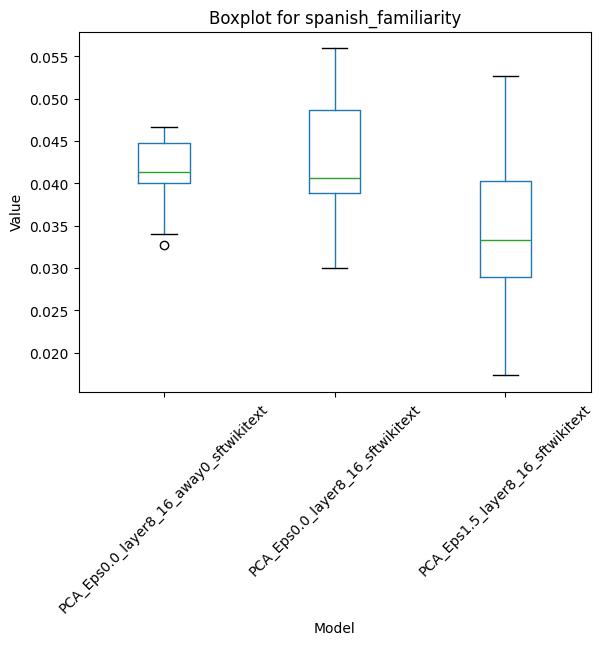

<Figure size 1000x600 with 0 Axes>

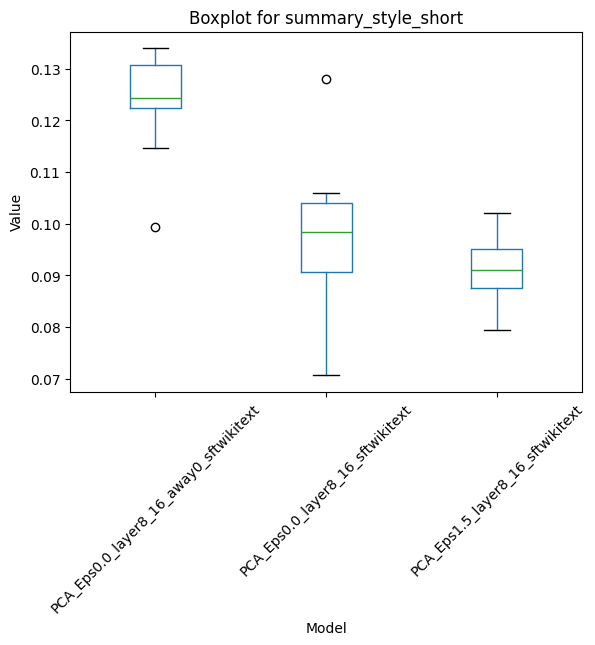

<Figure size 1000x600 with 0 Axes>

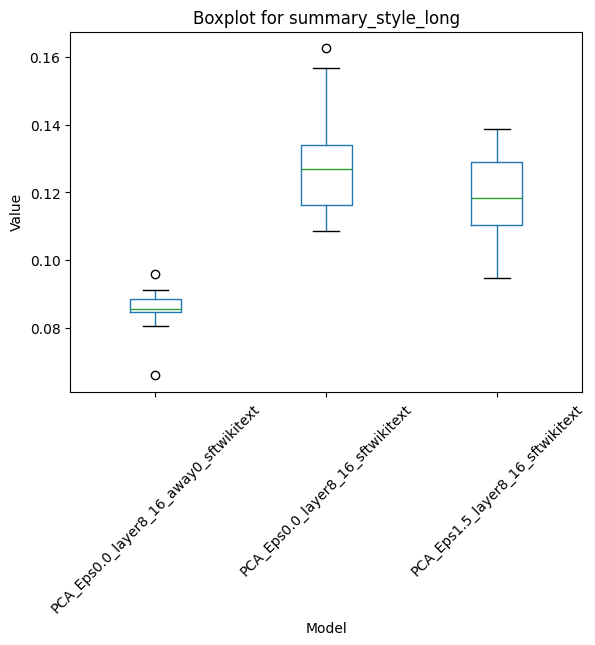

<Figure size 1000x600 with 0 Axes>

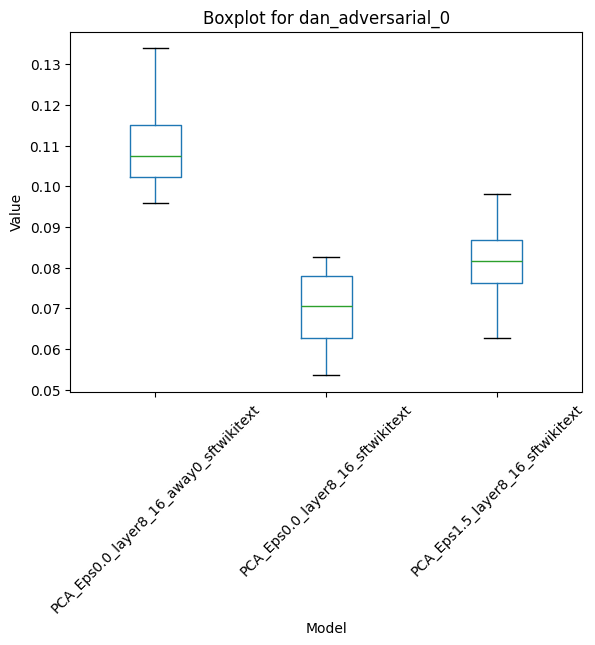

<Figure size 1000x600 with 0 Axes>

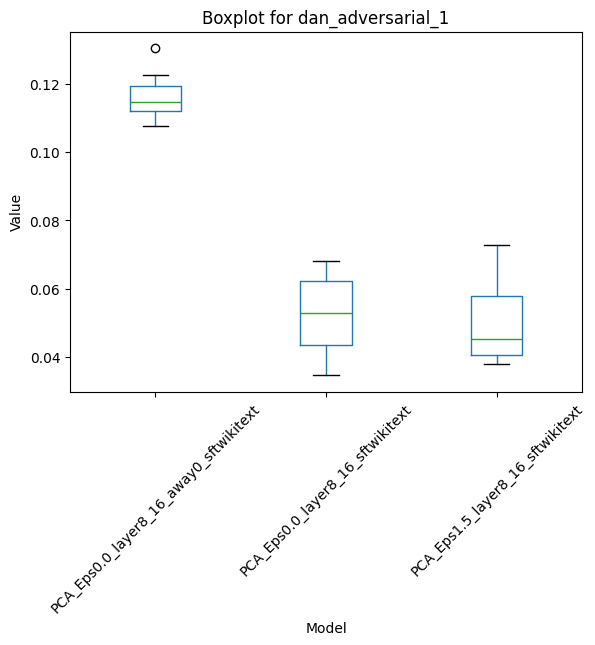

<Figure size 1000x600 with 0 Axes>

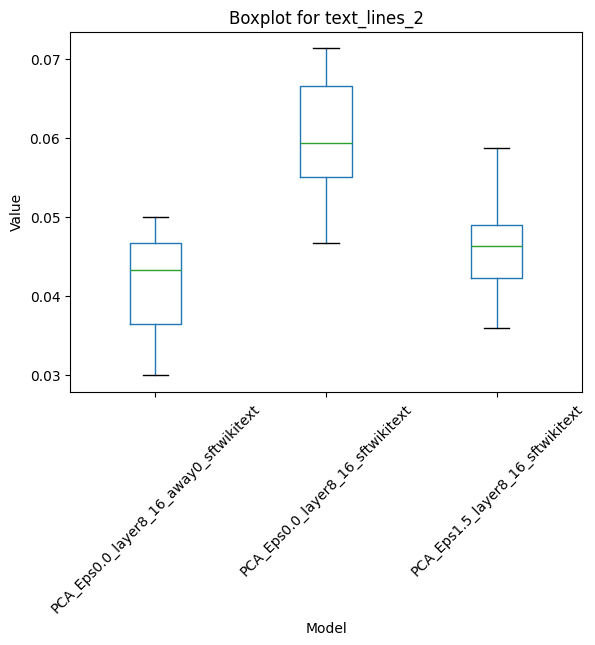

<Figure size 1000x600 with 0 Axes>

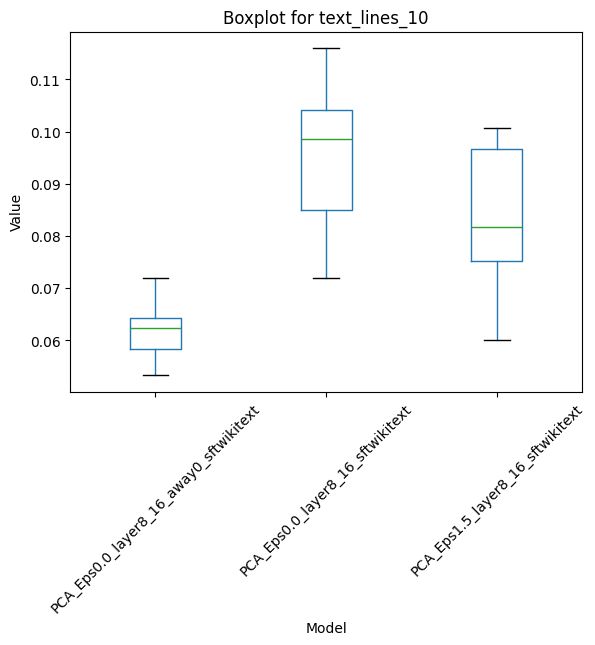

<Figure size 1000x600 with 0 Axes>

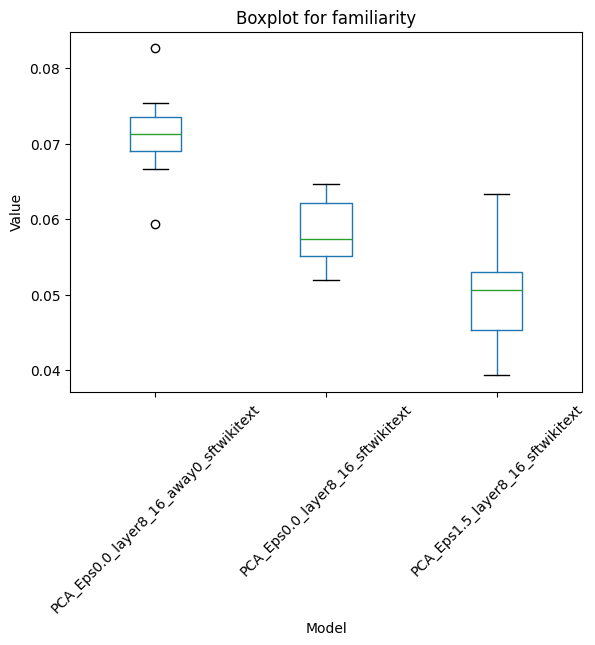

<Figure size 1000x600 with 0 Axes>

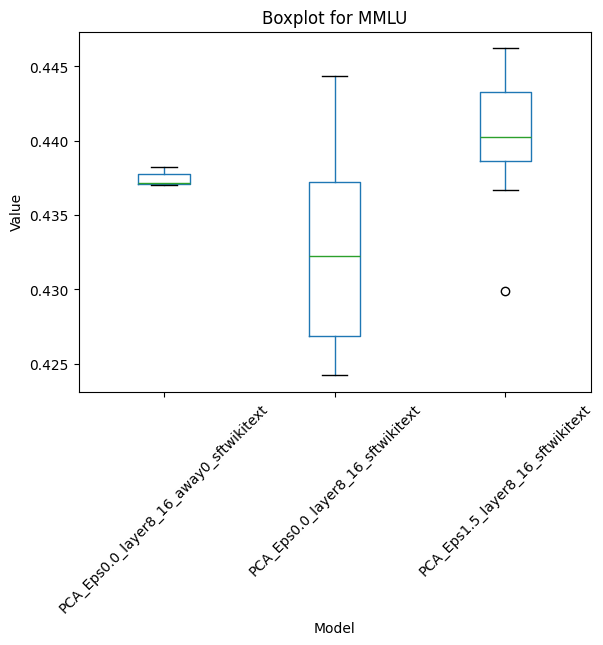

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Data
data = {
    'spanish_familiarity': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.05, 61: 0.04066666666666666, 62: 0.03933333333333334, 63: 0.03333333333333333, 64: 0.017333333333333333, 65: 0.028666666666666667, 66: 0.026, 67: 0.05266666666666667, 68: 0.03333333333333333, 69: 0.03},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.04266666666666667, 61: 0.04, 62: 0.046, 63: 0.03266666666666667, 64: 0.04533333333333333, 65: 0.04, 66: 0.04, 67: 0.04666666666666667, 68: 0.043333333333333335, 69: 0.033999999999999996},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.05, 61: 0.056, 62: 0.04, 63: 0.03, 64: 0.04933333333333333, 65: 0.03866666666666667, 66: 0.03666666666666667, 67: 0.03933333333333334, 68: 0.04133333333333333, 69: 0.04666666666666667}
    },
    'summary_style_short': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.09206666666666666, 61: 0.10200000000000001, 62: 0.09066666666666666, 63: 0.07933333333333334, 64: 0.09133333333333332, 65: 0.096, 66: 0.08666666666666667, 67: 0.08466666666666667, 68: 0.10066666666666667, 69: 0.09},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.12386666666666668, 61: 0.134, 62: 0.12400000000000001, 63: 0.11466666666666667, 64: 0.12466666666666666, 65: 0.13133333333333333, 66: 0.12866666666666668, 67: 0.09933333333333333, 68: 0.13333333333333333, 69: 0.12200000000000001},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.09673333333333332, 61: 0.07066666666666667, 62: 0.106, 63: 0.128, 64: 0.09066666666666666, 65: 0.09066666666666666, 66: 0.07666666666666666, 67: 0.104, 68: 0.104, 69: 0.1}
    },
    'summary_style_long': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.1195731910636879, 61: 0.11599999999999999, 62: 0.13866666666666666, 63: 0.108, 64: 0.11733333333333335, 65: 0.10836120401337793, 66: 0.09466666666666666, 67: 0.12200000000000001, 68: 0.13799999999999998, 69: 0.13133333333333333},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.08559973270965586, 61: 0.08428093645484949, 62: 0.066, 63: 0.096, 64: 0.08896321070234114, 65: 0.08561872909698998, 66: 0.08762541806020066, 67: 0.08053691275167785, 68: 0.09133333333333332, 69: 0.08533333333333334},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.1308, 61: 0.11133333333333333, 62: 0.16266666666666665, 63: 0.134, 64: 0.134, 65: 0.12266666666666666, 66: 0.10866666666666668, 67: 0.12333333333333334, 68: 0.114, 69: 0.15666666666666668}
    },
    'dan_adversarial_0': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.08333333333333333, 61: 0.06266666666666666, 62: 0.09733333333333333, 63: 0.074, 64: 0.07666666666666666, 65: 0.076, 66: 0.08266666666666667, 67: 0.08066666666666666, 68: 0.09799999999999999, 69: 0.088},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.096, 61: 0.11533333333333334, 62: 0.106, 63: 0.134, 64: 0.10133333333333333, 65: 0.10466666666666666, 66: 0.11466666666666667, 67: 0.10066666666666667, 68: 0.10866666666666668, 69: 0.11866666666666667},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.07933333333333334, 61: 0.07826086956521738, 62: 0.08266666666666667, 63: 0.07133333333333333, 64: 0.06666666666666667, 65: 0.06956521739130435, 66: 0.07733333333333334, 67: 0.05351170568561873, 68: 0.06133333333333333, 69: 0.057999999999999996}
    },
    'dan_adversarial_1': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.07266666666666667, 61: 0.05333333333333334, 62: 0.04733333333333333, 63: 0.04, 64: 0.043333333333333335, 65: 0.03866666666666667, 66: 0.04266666666666667, 67: 0.038, 68: 0.059333333333333335, 69: 0.06133333333333333},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.1076923076923077, 61: 0.11133333333333333, 62: 0.11533333333333334, 63: 0.12240802675585284, 64: 0.11505016722408026, 65: 0.12066666666666667, 66: 0.114, 67: 0.11304347826086955, 68: 0.1117056856187291, 69: 0.13043478260869565},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.064, 61: 0.048160535117056855, 62: 0.06799999999999999, 63: 0.03733333333333333, 64: 0.041999999999999996, 65: 0.051333333333333335, 66: 0.06666666666666667, 67: 0.034666666666666665, 68: 0.05466666666666666, 69: 0.05733333333333333}
    },
    'text_lines_2': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.04466666666666667, 61: 0.05866666666666667, 62: 0.048, 63: 0.048, 64: 0.043333333333333335, 65: 0.03733333333333333, 66: 0.04933333333333333, 67: 0.041999999999999996, 68: 0.056, 69: 0.036000000000000004},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.035333333333333335, 61: 0.04733333333333333, 62: 0.04466666666666667, 63: 0.03, 64: 0.041999999999999996, 65: 0.04466666666666667, 66: 0.05, 67: 0.04, 68: 0.035333333333333335, 69: 0.048666666666666664},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.054, 61: 0.06666666666666667, 62: 0.059333333333333335, 63: 0.066, 64: 0.059333333333333335, 65: 0.057999999999999996, 66: 0.07133333333333333, 67: 0.07, 68: 0.04666666666666667, 69: 0.04666666666666667}
    },
    'text_lines_10': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.09733333333333333, 61: 0.08333333333333333, 62: 0.07666666666666666, 63: 0.09666666666666666, 64: 0.08, 65: 0.06, 66: 0.06133333333333333, 67: 0.07466666666666666, 68: 0.10066666666666667, 69: 0.09666666666666666},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.057999999999999996, 61: 0.07200000000000001, 62: 0.059333333333333335, 63: 0.06333333333333334, 64: 0.05333333333333334, 65: 0.062000000000000006, 66: 0.07066666666666667, 67: 0.06466666666666666, 68: 0.06266666666666666, 69: 0.054},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.07200000000000001, 61: 0.10466666666666666, 62: 0.082, 63: 0.10733333333333334, 64: 0.09533333333333334, 65: 0.10200000000000001, 66: 0.11599999999999999, 67: 0.08399999999999999, 68: 0.088, 69: 0.10266666666666667}
    },
    'familiarity': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.06333333333333334, 61: 0.04733333333333333, 62: 0.03933333333333334, 63: 0.05, 64: 0.043333333333333335, 65: 0.051333333333333335, 66: 0.052, 67: 0.05333333333333334, 68: 0.056, 69: 0.04466666666666667},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.07, 61: 0.07200000000000001, 62: 0.06666666666666667, 63: 0.074, 64: 0.07133333333333333, 65: 0.07533333333333334, 66: 0.08266666666666667, 67: 0.06866666666666667, 68: 0.059333333333333335, 69: 0.07133333333333333},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.057999999999999996, 61: 0.056666666666666664, 62: 0.06333333333333334, 63: 0.05333333333333334, 64: 0.06466666666666666, 65: 0.05466666666666666, 66: 0.056666666666666664, 67: 0.05866666666666667, 68: 0.06466666666666666, 69: 0.052}
    },
    'MMLU': {
        'PCA_Eps1.5_layer8_16_sftwikitext': {60: 0.4406779661016949, 61: 0.4393960974220197, 62: 0.44003703176185727, 63: 0.4383990884489389, 64: 0.44502207662726107, 65: 0.42992451217775246, 66: 0.44039310639510043, 67: 0.4441674975074776, 68: 0.43668993020937186, 69: 0.4462327303802877},
        'PCA_Eps0.0_layer8_16_away0_sftwikitext': {60: 0.437046004842615, 61: 0.4379005839623985, 62: 0.43825665859564167, 63: 0.43711721976926365, 64: 0.437046004842615, 65: 0.4379005839623985, 66: 0.43711721976926365, 67: 0.43711721976926365, 68: 0.43747329440250676, 69: 0.43725964962256086},
        'PCA_Eps0.0_layer8_16_sftwikitext': {60: 0.4443811422874234, 61: 0.42935479276456345, 62: 0.42657741062526705, 63: 0.43519441674975073, 64: 0.42771684945164506, 65: 0.43825665859564167, 66: 0.43597778094288564, 67: 0.43761572425580403, 68: 0.4242273180458624, 69: 0.4246546076057542}
    }
}

# Converting the nested dictionary into a pandas DataFrame
def convert_to_df(data):
    rows = []
    for evaluation_type, models in data.items():
        for model_name, values in models.items():
            for key, value in values.items():
                rows.append([evaluation_type, model_name, key, value])
    return pd.DataFrame(rows, columns=['Evaluation Type', 'Model', 'Key', 'Value'])

df = convert_to_df(data)

# Plotting boxplots
evaluation_types = df['Evaluation Type'].unique()
for evaluation_type in evaluation_types:
    subset = df[df['Evaluation Type'] == evaluation_type]
    plt.figure(figsize=(10, 6))
    subset.boxplot(by='Model', column='Value', grid=False)
    plt.title(f'Boxplot for {evaluation_type}')
    plt.suptitle('')
    plt.xlabel('Model')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.show()

# Running t-tests
ttest_results = {}
for evaluation_type in evaluation_types:
    subset = df[df['Evaluation Type'] == evaluation_type]
    models = subset['Model'].unique()
    for i in range(len(models)):
        for j in range(i+1, len(models)):
            model1 = subset[subset['Model'] == models[i]]['Value']
            model2 = subset[subset['Model'] == models[j]]['Value']
            t_stat, p_val = ttest_ind(model1, model2)
            ttest_results[f'{evaluation_type} ({models[i]} vs {models[j]})'] = (t_stat, p_val)

In [15]:
# Extract models' names
model_names = list(data['spanish_familiarity'].keys())

# Create a dictionary to store t-test results
ttest_results = {}

# Loop through each evaluation type and perform t-tests
for evaluation_type in data.keys():
    # Extract the values for each model
    model1_values = list(data[evaluation_type]['PCA_Eps1.5_layer8_16_sftwikitext'].values())
    model2_values = list(data[evaluation_type]['PCA_Eps0.0_layer8_16_away0_sftwikitext'].values())
    model3_values = list(data[evaluation_type]['PCA_Eps0.0_layer8_16_sftwikitext'].values())
    
    # Perform t-tests
    ttest_1_2 = ttest_ind(model1_values, model2_values)
    ttest_1_3 = ttest_ind(model1_values, model3_values)
    
    # Store the results
    ttest_results[f'{evaluation_type} PCA_Eps1.5 vs PCA_Eps0.0_away0'] = {'t-statistic': ttest_1_2.statistic, 'p-value': ttest_1_2.pvalue}
    ttest_results[f'{evaluation_type} PCA_Eps1.5 vs PCA_Eps0.0'] = {'t-statistic': ttest_1_3.statistic, 'p-value': ttest_1_3.pvalue}

# Convert the results to a DataFrame
ttest_results_df = pd.DataFrame.from_dict(ttest_results, orient='index')

# Display the DataFrame
print(ttest_results_df)

                                                    t-statistic       p-value
spanish_familiarity PCA_Eps1.5 vs PCA_Eps0.0_away0    -1.587571  1.297938e-01
spanish_familiarity PCA_Eps1.5 vs PCA_Eps0.0          -1.832180  8.352318e-02
summary_style_short PCA_Eps1.5 vs PCA_Eps0.0_away0    -8.185897  1.764194e-07
summary_style_short PCA_Eps1.5 vs PCA_Eps0.0          -0.973161  3.433706e-01
summary_style_long PCA_Eps1.5 vs PCA_Eps0.0_away0      6.760966  2.464412e-06
summary_style_long PCA_Eps1.5 vs PCA_Eps0.0           -1.439754  1.671029e-01
dan_adversarial_0 PCA_Eps1.5 vs PCA_Eps0.0_away0      -5.757049  1.860598e-05
dan_adversarial_0 PCA_Eps1.5 vs PCA_Eps0.0             2.636118  1.677348e-02
dan_adversarial_1 PCA_Eps1.5 vs PCA_Eps0.0_away0     -15.716189  5.891697e-12
dan_adversarial_1 PCA_Eps1.5 vs PCA_Eps0.0            -0.521995  6.080384e-01
text_lines_2 PCA_Eps1.5 vs PCA_Eps0.0_away0            1.461399  1.611441e-01
text_lines_2 PCA_Eps1.5 vs PCA_Eps0.0                 -3.713810 

In [11]:
all_dicts.keys()

dict_keys(['capability', 'full_capability', 'spanish_familiarity', 'summary_style', 'trivia', 'dan_adversarial', 'familiarity', 'text_lines', 'side_effect_familiarity'])

In [12]:
combine_runs_separated(all_dicts['text_lines'])

{'PCA_Eps0.5_layer8_16_sftwikitext': {2: {60: 0.05466666666666666,
   61: 0.050666666666666665,
   62: 0.038,
   63: 0.044,
   64: 0.044,
   65: 0.052,
   66: 0.051333333333333335,
   67: 0.05333333333333334,
   68: 0.07,
   69: 0.052},
  10: {60: 0.10533333333333333,
   61: 0.11733333333333335,
   62: 0.088,
   63: 0.09,
   64: 0.10666666666666667,
   65: 0.074,
   66: 0.08666666666666667,
   67: 0.14,
   68: 0.10666666666666667,
   69: 0.08733333333333333}},
 'PCA_Eps1.0_layer8_16_sftwikitext': {2: {60: 0.046,
   61: 0.05,
   62: 0.05866666666666667,
   63: 0.051333333333333335,
   64: 0.051333333333333335,
   65: 0.056,
   66: 0.051333333333333335,
   67: 0.056666666666666664,
   68: 0.057999999999999996,
   69: 0.04133333333333333},
  10: {60: 0.09466666666666666,
   61: 0.07133333333333333,
   62: 0.096,
   63: 0.08133333333333333,
   64: 0.064,
   65: 0.09,
   66: 0.08333333333333333,
   67: 0.09133333333333332,
   68: 0.114,
   69: 0.06933333333333333}},
 'PCA_Eps1.5_layer8_16_s

In [9]:
all_dicts['full_capability'].keys()

dict_keys(['WHP_Original', 'LLaMA', 'PCA_Eps0.5_layer8_16_sftwikitext_60', 'PCA_Eps1.0_layer8_16_sftwikitext_60', 'PCA_Eps1.5_layer8_16_sftwikitext_60', 'PCA_Eps3.0_layer8_16_sftwikitext_60', 'PCA_Eps6.0_layer8_16_sftwikitext_60', 'PCA_Eps0.5_layer8_16_sftwikitext_61', 'PCA_Eps1.0_layer8_16_sftwikitext_61', 'PCA_Eps1.5_layer8_16_sftwikitext_61', 'PCA_Eps3.0_layer8_16_sftwikitext_61', 'PCA_Eps6.0_layer8_16_sftwikitext_61', 'PCA_Eps0.5_layer8_16_sftwikitext_62', 'PCA_Eps1.0_layer8_16_sftwikitext_62', 'PCA_Eps1.5_layer8_16_sftwikitext_62', 'PCA_Eps3.0_layer8_16_sftwikitext_62', 'PCA_Eps6.0_layer8_16_sftwikitext_62', 'PCA_Eps0.5_layer8_16_sftwikitext_63', 'PCA_Eps1.0_layer8_16_sftwikitext_63', 'PCA_Eps1.5_layer8_16_sftwikitext_63', 'PCA_Eps3.0_layer8_16_sftwikitext_63', 'PCA_Eps6.0_layer8_16_sftwikitext_63', 'PCA_Eps0.5_layer8_16_sftwikitext_64', 'PCA_Eps1.0_layer8_16_sftwikitext_64', 'PCA_Eps1.5_layer8_16_sftwikitext_64', 'PCA_Eps3.0_layer8_16_sftwikitext_64', 'PCA_Eps6.0_layer8_16_sftwik

In [10]:
"""
aggregated_familiarity_dict = {}
# save_dir = f"results/llama-lat-sweep-1"
# save_dir = f"results/llama-lat-sweep-2"
# save_dir = f"results/llama-lat-pca-sweep"
# save_dir = f"results/llama-lat-pca-data-sweep"
# save_dir = f"results/lat-data-comparison"
# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"
# models = {"HP-MSR": hp_model}

with open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
aggregated_familiarity_dict['PCA_L8_Eps1'] = familiarity_dict['PCA_Eps1']
aggregated_familiarity_dict['PCA_L8_Eps10'] = familiarity_dict['PCA_Eps10']
aggregated_familiarity_dict['PCA_L8_Eps100'] = familiarity_dict['PCA_Eps100']

with open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict['Pile_PCA_L8_Eps1'] = familiarity_dict['Pile_PCA']
aggregated_familiarity_dict['HP_Only_All_Indices_PCA_L8_Eps1'] = familiarity_dict['HP_Only_All_Indices_PCA']

with open("results/llama-lat-sweep-2/familiarity_dict.pkl", "rb") as f:
    familiarity_dict = pickle.load(f)
familiarity_dict
aggregated_familiarity_dict["No_PCA_L8_Eps1"] = familiarity_dict["WHP_L8_Eps1"]
aggregated_familiarity_dict["No_PCA_L8_Eps10"] = familiarity_dict["WHP_L8_Eps10"]
aggregated_familiarity_dict["No_PCA_L15_Eps1"] = familiarity_dict["WHP_L15_Eps1"]
aggregated_familiarity_dict["No_PCA_L20_Eps1"] = familiarity_dict["WHP_L20_Eps1"]

familiarity_scores = {model: get_familiarity_score(aggregated_familiarity_dict[model]) for model in aggregated_familiarity_dict}

with open("results/final_paper_results/familiarity_dict.pkl", "rb") as f:
    old_familiarity_dict = pickle.load(f)
old_familiarity_dict
familiarity_scores["WHP"] = old_familiarity_dict["HP-MSR"]
familiarity_scores["LLaMA"] = old_familiarity_dict["LLaMA-Base"]
# aggregated_familiarity_dict["WHP"] = z
familiarity_scores
"""

'\naggregated_familiarity_dict = {}\n# save_dir = f"results/llama-lat-sweep-1"\n# save_dir = f"results/llama-lat-sweep-2"\n# save_dir = f"results/llama-lat-pca-sweep"\n# save_dir = f"results/llama-lat-pca-data-sweep"\n# save_dir = f"results/lat-data-comparison"\n# save_dir = f"results/llama-lat-results-gen-diff-hp-indices"\n# models = {"HP-MSR": hp_model}\n\nwith open("results/llama-lat-pca-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\naggregated_familiarity_dict[\'PCA_L8_Eps1\'] = familiarity_dict[\'PCA_Eps1\']\naggregated_familiarity_dict[\'PCA_L8_Eps10\'] = familiarity_dict[\'PCA_Eps10\']\naggregated_familiarity_dict[\'PCA_L8_Eps100\'] = familiarity_dict[\'PCA_Eps100\']\n\nwith open("results/llama-lat-pca-data-sweep/familiarity_dict.pkl", "rb") as f:\n    familiarity_dict = pickle.load(f)\nfamiliarity_dict\naggregated_familiarity_dict[\'Pile_PCA_L8_Eps1\'] = familiarity_dict[\'Pile_PCA\']\naggregated_familiarity_dict[\'HP_Only_All_Indices_PCA_L8_Ep

In [11]:
# with open(f"{save_dir}/familiarity_dict.pkl", "rb") as f:
#     familiarity_dict = pickle.load(f)
familiarity_dict = combine_runs(all_dicts['familiarity'])
familiarity_scores = {model: get_familiarity_score(familiarity_dict[model]) for model in familiarity_dict}

In [12]:
familiarity_scores

{'PCA_Eps0.5_layer8_16_sftwikitext': 0.049266666666666674,
 'PCA_Eps1.0_layer8_16_sftwikitext': 0.049133333333333334,
 'PCA_Eps1.5_layer8_16_sftwikitext': 0.05006666666666666,
 'PCA_Eps3.0_layer8_16_sftwikitext': 0.05960000000000001,
 'PCA_Eps6.0_layer8_16_sftwikitext': 0.057600000000000005,
 'PCA_Eps0.0_layer8_16_away0_sftwikitext': 0.07113333333333334,
 'PCA_Eps0.0_layer8_16_sftwikitext': 0.05826666666666667,
 'LLaMA': 0.4666666666666667,
 'WHP_Original': 0.16333333333333333}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


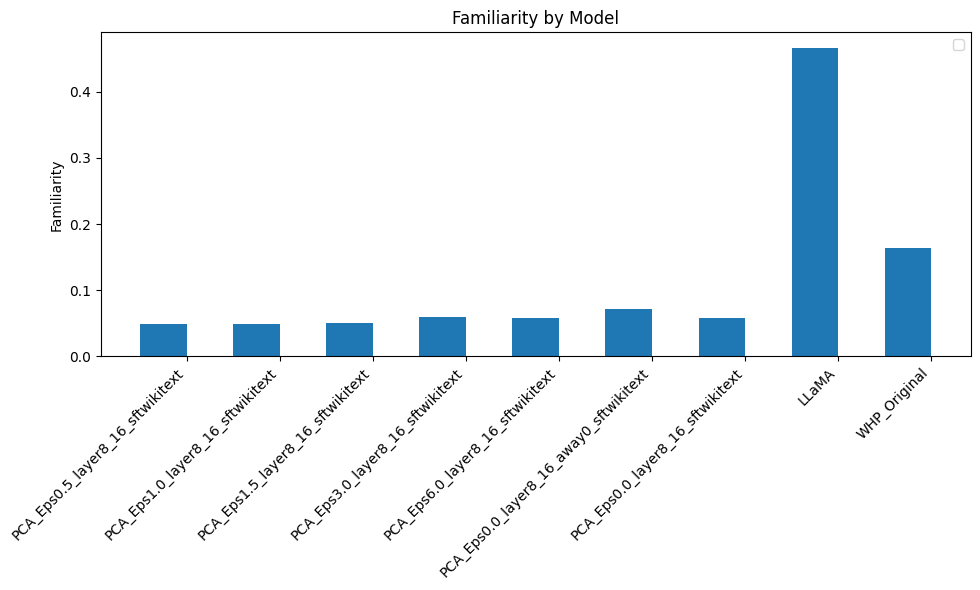

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.5  # width of the bars
index = np.arange(len(familiarity_scores))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, familiarity_scores.values(), bar_width)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Familiarity')
ax.set_title('Familiarity by Model')
ax.set_xticks(index)
ax.set_xticklabels(familiarity_scores.keys(), rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

## Capability vs Familiarity

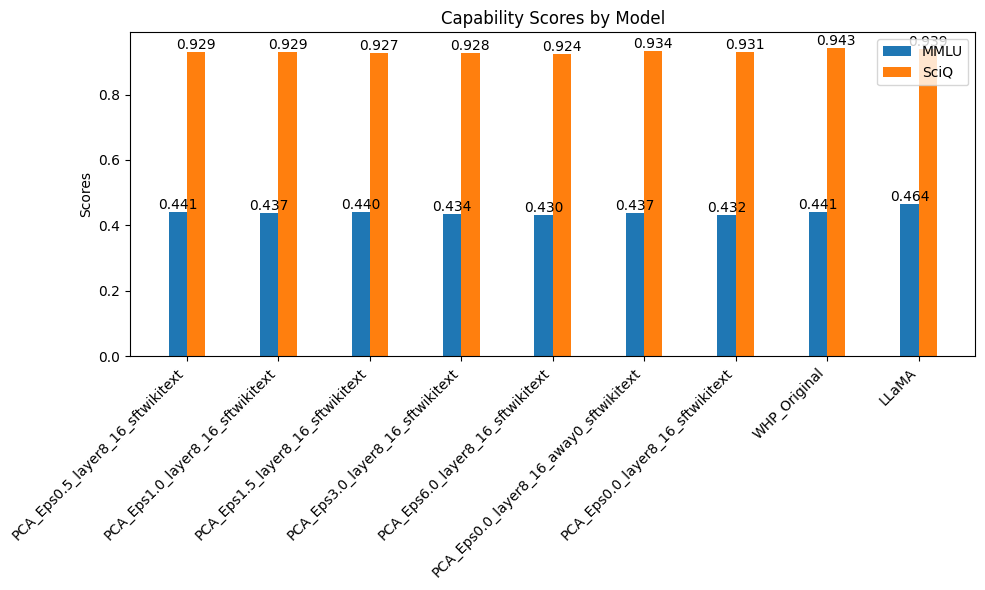

In [14]:
import matplotlib.pyplot as plt
import numpy as np
# with open(f"{save_dir}/capability_dict.pkl", "rb") as f:
#     capability_dict = pickle.load(f)
capability_dict = combine_capabilities(all_dicts['full_capability'])

# Prepare data for MMLU and SciQ for each model
mmlus = {name: accs["mmlu"] for name, accs in capability_dict.items()}
sciqs = {name: accs["sciq"] for name, accs in capability_dict.items()}
# piqas = {name: accs["PIQA"] for name, accs in capability_dict.items()}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2  # width of the bars
index = np.arange(len(capability_dict))  # the label locations

# Plot each bar
bars1 = ax.bar(index - bar_width/2, mmlus.values(), bar_width, label='MMLU')
bars2 = ax.bar(index + bar_width/2, sciqs.values(), bar_width, label='SciQ')
# bars3 = ax.bar(index + 3*bar_width/2, piqas.values(), bar_width, label='PIQA')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Capability Scores by Model')
ax.set_xticks(index)
ax.set_xticklabels(capability_dict.keys(), rotation=45, ha="right")
ax.legend()

# Adding the score values on top of the bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4498/2814795019.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(models_list))  # 'tab20' is a qualitative colormap with 20 distinct colors


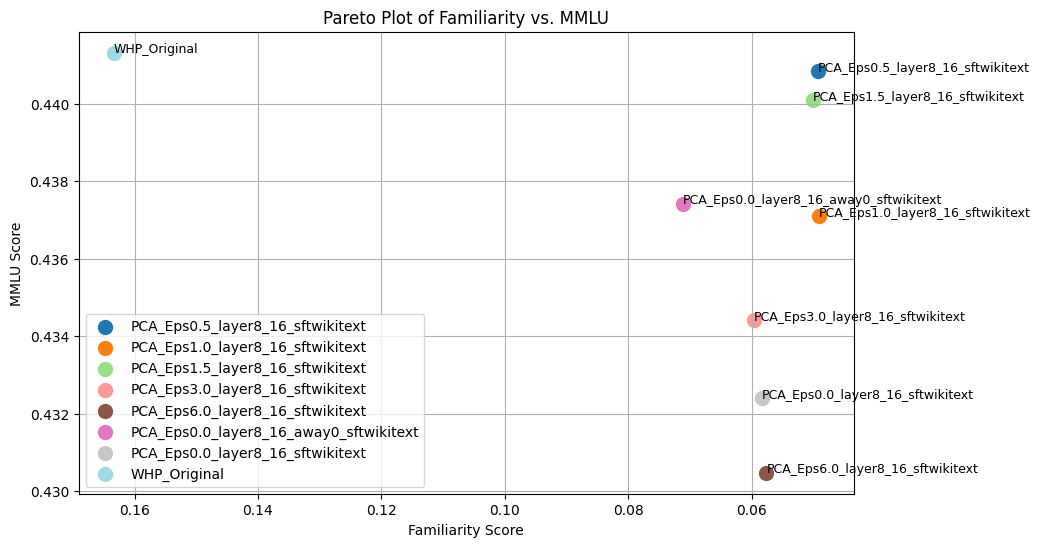

In [15]:
# Plot Pareto Plot, x-axis is familiarity, y-axis is capability
capability_name = "MMLU"
ability_dict = mmlus
ignore_models = ["LLaMA"]
# ignore_models = []

models_list = list(familiarity_scores.keys())  # Assuming familiarity_scores is globally defined and includes all models
colors = plt.cm.get_cmap('tab20', len(models_list))  # 'tab20' is a qualitative colormap with 20 distinct colors
color_map = {model: colors(i) for i, model in enumerate(models_list)}


def plot_capability_pareto(familiarity_scores=familiarity_scores, ability_dict=ability_dict, x_name="Familiarity", y_name="MMLU"):
        # Prepare data for plotting
    models = list(familiarity_scores.keys())
    models = [model for model in models if model not in ignore_models]
    familiarity_values = [familiarity_scores[model] for model in models]
    capability_values = [ability_dict[model] for model in models]

    # Plotting
    plt.figure(figsize=(10, 6))
    for i, model in enumerate(models):
        plt.scatter(familiarity_values[i], capability_values[i], label=model, s=100, color=color_map[model])

    plt.xlabel(f'{x_name} Score')
    plt.ylabel(f'{y_name} Score')
    plt.title(f'Pareto Plot of {x_name} vs. {y_name}')
    plt.legend()

    # Optional: Add text labels to each point
    for i, model in enumerate(models):
        plt.text(familiarity_values[i], capability_values[i], model, fontsize=9)

    plt.grid(True)
    plt.gca().invert_xaxis()  # This line inverts the x-axis
    plt.show()

plot_capability_pareto(ability_dict=mmlus, y_name="MMLU")
# plot_capability_pareto(ability_dict=sciqs, y_name="SciQ")


## Adversarial Results

In [16]:
all_dicts.keys()

dict_keys(['capability', 'full_capability', 'spanish_familiarity', 'summary_style', 'trivia', 'dan_adversarial', 'familiarity', 'text_lines', 'side_effect_familiarity'])

In [17]:
# with open(f"{save_dir}/chat_familiarity_dict.pkl", "rb") as f:
#     chat_familiarity_dict = pickle.load(f)

# with open(f"{save_dir}/dan_adversarial_dict.pkl", "rb") as f:
#     dan_adversarial_dict = pickle.load(f)

# with open(f"{save_dir}/spanish_familiarity_dict.pkl", "rb") as f:
#     spanish_familiarity_dict = pickle.load(f)

# with open(f"{save_dir}/summary_style_dict.pkl", "rb") as f:
#     summary_style_dict = pickle.load(f)

# with open(f"{save_dir}/text_lines_dict.pkl", "rb") as f:
#     text_lines_dict = pickle.load(f)

spanish_familiarity_dict = combine_runs(all_dicts['spanish_familiarity'])
summary_style_dict = combine_runs(all_dicts['summary_style'])

text_lines_dict = combine_runs(all_dicts['text_lines'])
dan_adversarial_dict = combine_runs(all_dicts['dan_adversarial'])

In [18]:
# with open("results/final_paper_results/text_lines_dict.pkl", "rb") as f:
#     old_text_lines_dict = pickle.load(f)
# old_text_lines_dict

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# model_order = list(capability_dict.keys())
model_order = list(familiarity_dict.keys())


# Combine all dictionaries into a single DataFrame
data = []
for name, dict_ in [
    ("Baseline Familiarity", familiarity_dict),
    ("Spanish", spanish_familiarity_dict), 
                    #  ("Chat Prompt", chat_familiarity_dict),
                     ("DAN Prompts", dan_adversarial_dict), 
                     ("Summary Style", summary_style_dict), 
                     ("Text Lines", text_lines_dict)
                      ]:
    for model in model_order:
        # get first key of dict_[model]
        try:
            sample_key = list(dict_[model].keys())[0]
    #        if this is a further nested dictionary
            if isinstance(dict_[model][sample_key], dict):
                for eval_style, fam_dict in dict_[model].items():
                    data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": get_familiarity_score(fam_dict)})
            else:
                data.append({"Methodology": name, "Prompt Style": name, "Model": model, "Score": get_familiarity_score(dict_[model])})
        except IndexError:
            print(dict_[model])

        # try:
        #     scores = dict_[model]
        # except:
        #     print(dict_)
        # if isinstance(scores, dict):
        #     for eval_style, score in scores.items():
        #         data.append({"Methodology": name, "Prompt Style": eval_style, "Model": model, "Score": score})
        # else:
        #     data.append({"Methodology": name, "Prompt Style": "Chat", "Model": model, "Score": scores})

# data.append({"Methodology": "Text Lines", "Prompt Style": 2, "Model": "LLaMA", "Score": 1.7941176470588236})
# data.append({"Methodology": "Text Lines", "Prompt Style": 10, "Model": "LLaMA", "Score": 1.9064748201438848})

df = pd.DataFrame(data)
df

,Methodology,Prompt Style,Model,Score
0,Baseline Familiarity,Baseline Familiarity,PCA_Eps0.5_layer8_16_sftwikitext,0.049267
1,Baseline Familiarity,Baseline Familiarity,PCA_Eps1.0_layer8_16_sftwikitext,0.049133
2,Baseline Familiarity,Baseline Familiarity,PCA_Eps1.5_layer8_16_sftwikitext,0.050067
3,Baseline Familiarity,Baseline Familiarity,PCA_Eps3.0_layer8_16_sftwikitext,0.059600
4,Baseline Familiarity,Baseline Familiarity,PCA_Eps6.0_layer8_16_sftwikitext,0.057600
...,...,...,...,...
67,Text Lines,10,PCA_Eps0.0_layer8_16_sftwikitext,0.095400
68,Text Lines,2,LLaMA,0.254000
69,Text Lines,10,LLaMA,0.294983
70,Text Lines,2,WHP_Original,0.126000


In [20]:
# unique entries in df["Prompt Style"]
df["Prompt Style"].unique()

array(['Baseline Familiarity', 'Spanish', 0, 1, 'short', 'long', 2, 10],
      dtype=object)

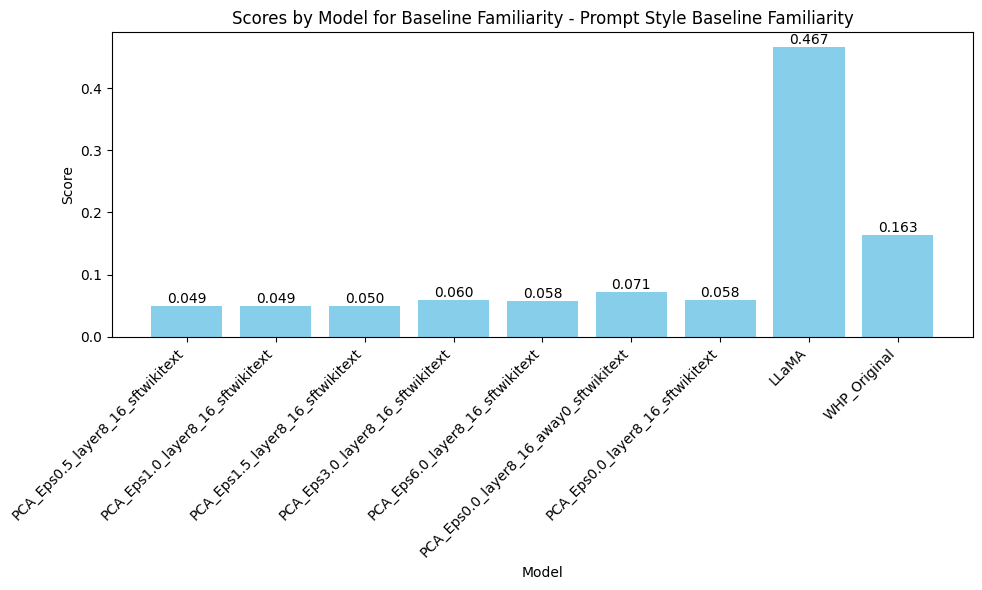

In [21]:
import matplotlib.pyplot as plt

def plot_scores_by_methodology_and_prompt(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    
    # Check if the filtered DataFrame is empty
    if filtered_df.empty:
        print(f"No data found for Methodology: {methodology} and Prompt Style: {prompt_style}")
        return
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(filtered_df['Model'], filtered_df['Score'], color='skyblue')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.title(f'Scores by Model for {methodology} - Prompt Style {prompt_style}')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Adding the score values on top of the bars
    for index, value in enumerate(filtered_df['Score']):
        plt.text(index, value, f"{value:.3f}", ha='center', va='bottom')
    
    plt.show()

# Example usage
plot_scores_by_methodology_and_prompt(df, 'Baseline Familiarity', 'Baseline Familiarity')

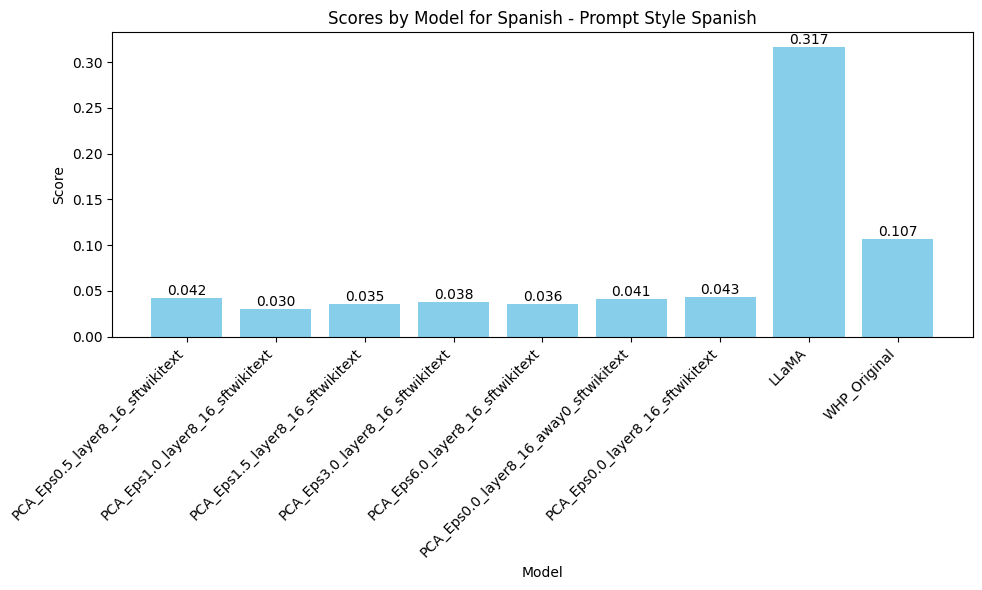

In [22]:
plot_scores_by_methodology_and_prompt(df, 'Spanish', 'Spanish')

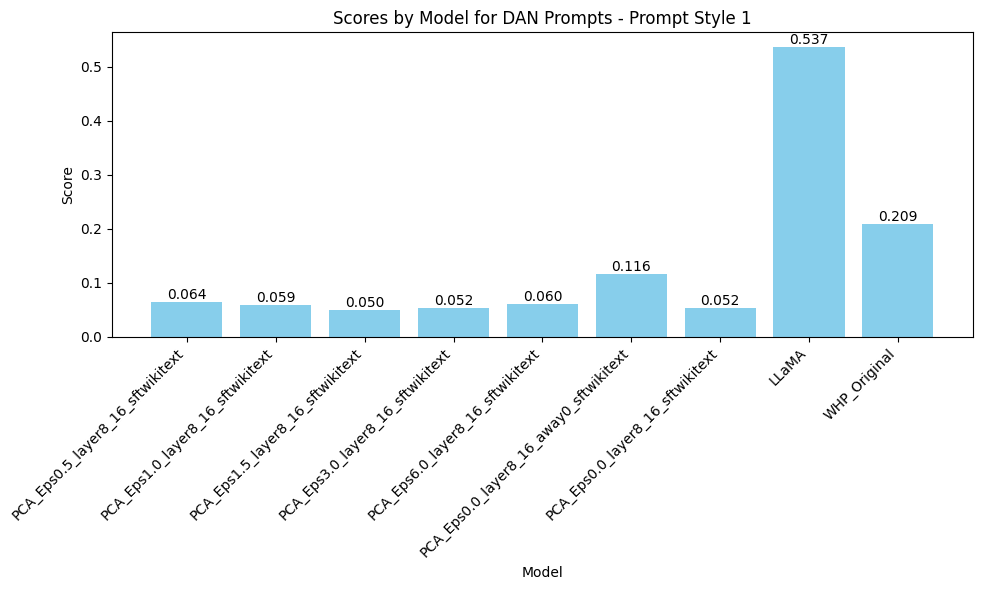

In [23]:
# plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 0)
plot_scores_by_methodology_and_prompt(df, 'DAN Prompts', 1)

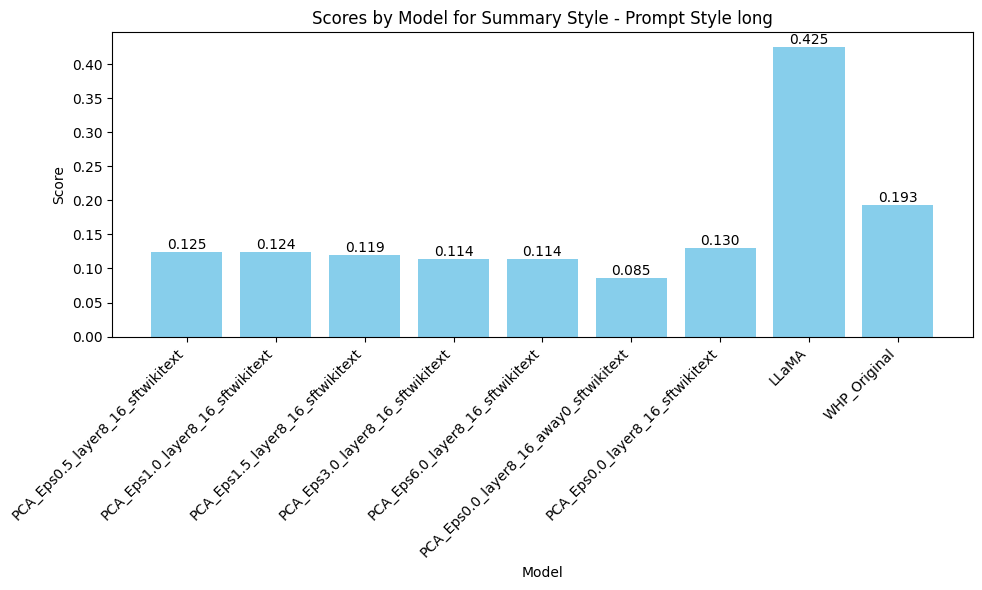

In [24]:
# plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'short')
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'long')

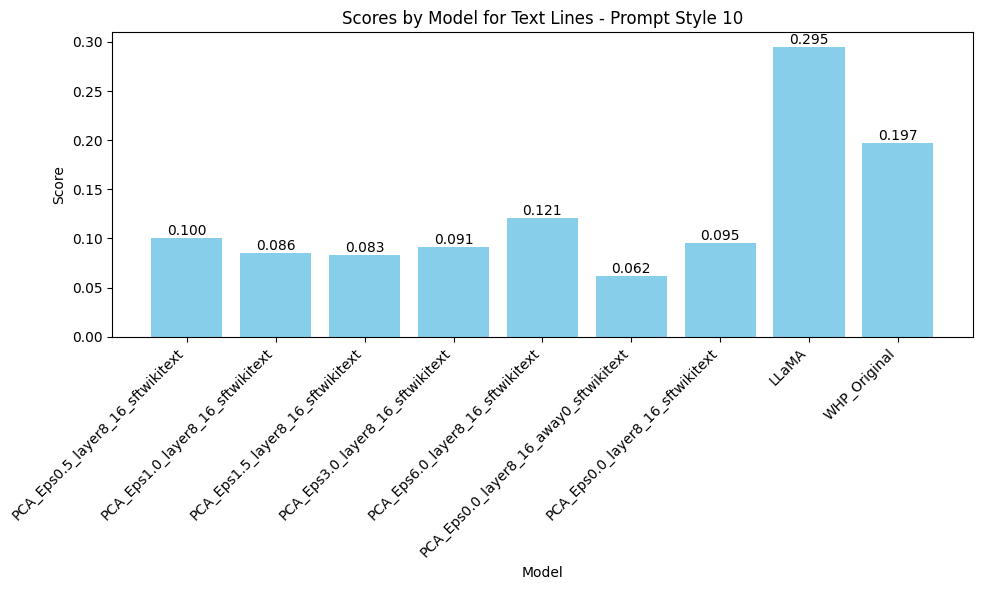

In [25]:
# plot_scores_by_methodology_and_prompt(df, 'Text Lines', 2)
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 10)

In [26]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(df)

             Methodology          Prompt Style  \
0   Baseline Familiarity  Baseline Familiarity   
1   Baseline Familiarity  Baseline Familiarity   
2   Baseline Familiarity  Baseline Familiarity   
3   Baseline Familiarity  Baseline Familiarity   
4   Baseline Familiarity  Baseline Familiarity   
5   Baseline Familiarity  Baseline Familiarity   
6   Baseline Familiarity  Baseline Familiarity   
7   Baseline Familiarity  Baseline Familiarity   
8   Baseline Familiarity  Baseline Familiarity   
9                Spanish               Spanish   
10               Spanish               Spanish   
11               Spanish               Spanish   
12               Spanish               Spanish   
13               Spanish               Spanish   
14               Spanish               Spanish   
15               Spanish               Spanish   
16               Spanish               Spanish   
17               Spanish               Spanish   
18           DAN Prompts                     0   


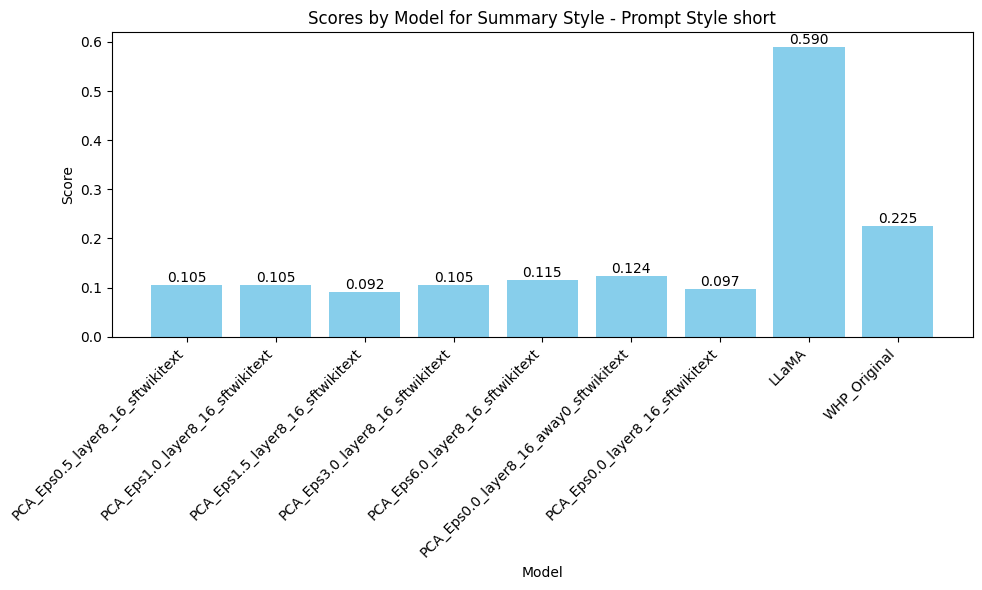

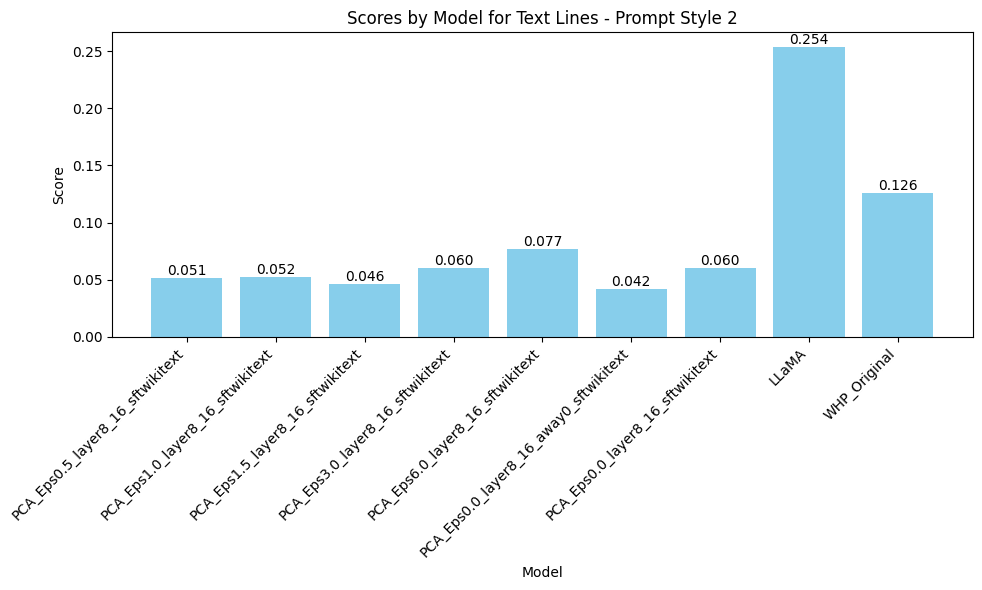

In [27]:
plot_scores_by_methodology_and_prompt(df, 'Summary Style', 'short')
plot_scores_by_methodology_and_prompt(df, 'Text Lines', 2)

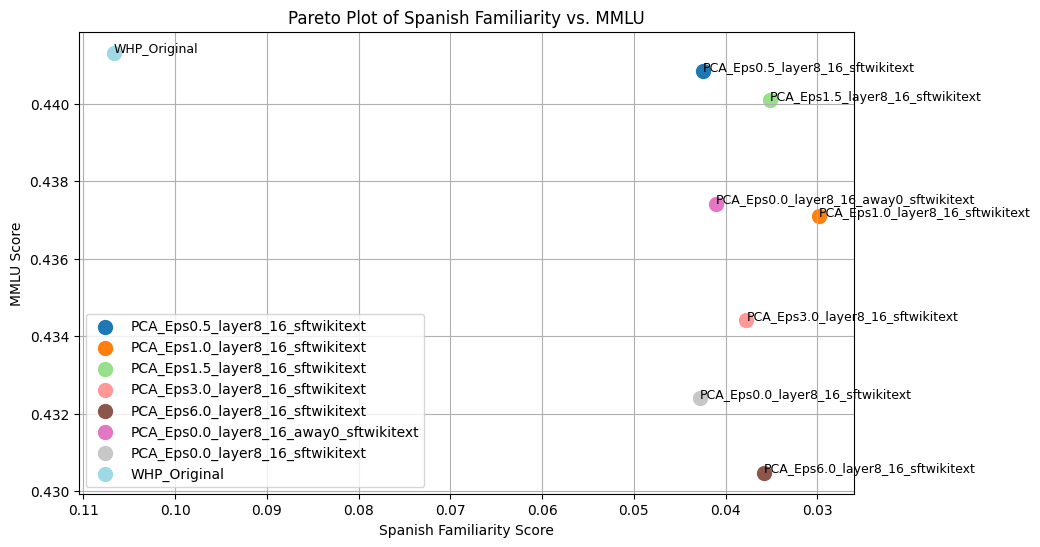

In [30]:
def get_fam_scores(df, methodology, prompt_style):
    # Filter the DataFrame
    filtered_df = df[(df['Methodology'] == methodology) & (df['Prompt Style'] == prompt_style)]
    # print(filtered_df)
    fam_scores = {}
    for model in filtered_df["Model"]:
        fam_scores[model] = filtered_df[filtered_df["Model"] == model]["Score"].values[0]
    return fam_scores

# get_fam_scores(df, 'Spanish', 'Spanish')
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Spanish', 'Spanish'), ability_dict={name: accs["mmlu"] for name, accs in capability_dict.items()}, x_name="Spanish Familiarity", y_name="MMLU")

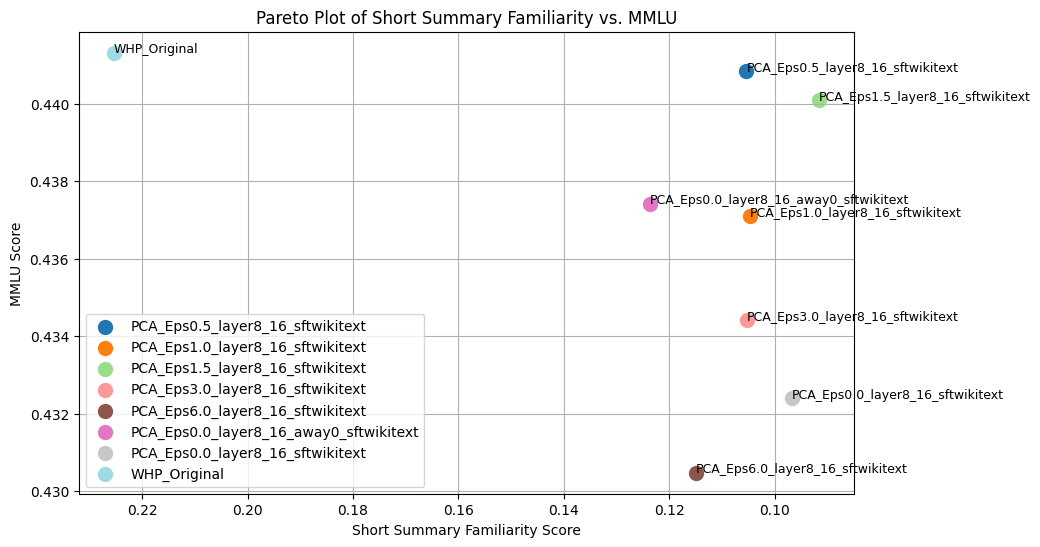

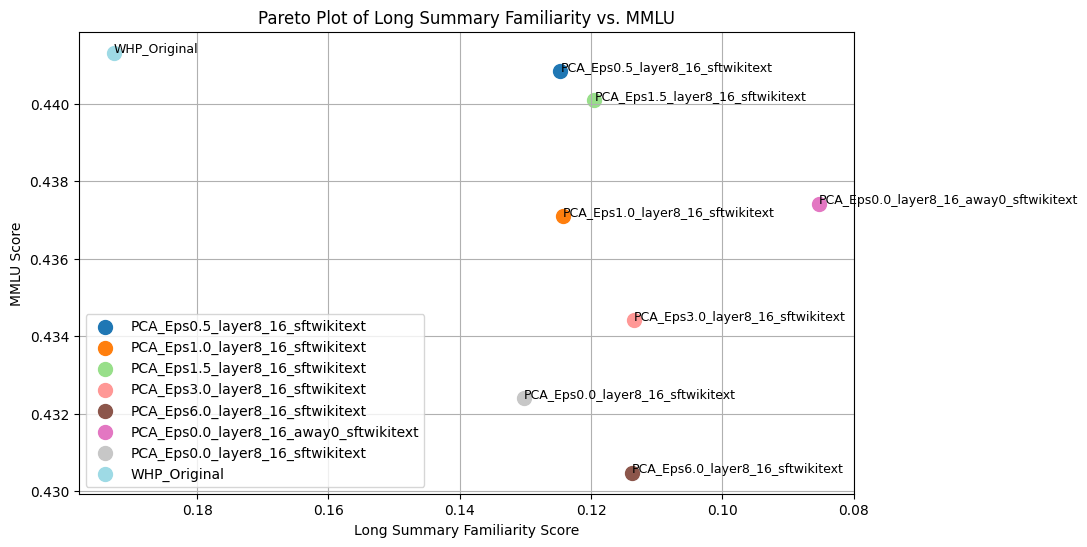

In [32]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'short'), ability_dict={name: accs["mmlu"] for name, accs in capability_dict.items()}, x_name="Short Summary Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'long'), ability_dict={name: accs["mmlu"] for name, accs in capability_dict.items()}, x_name="Long Summary Familiarity", y_name="MMLU")

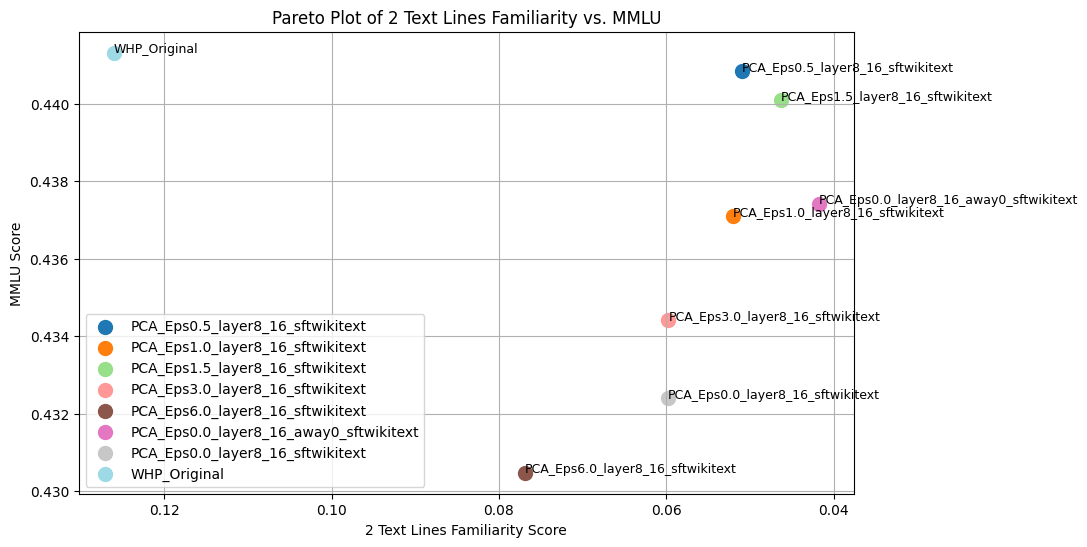

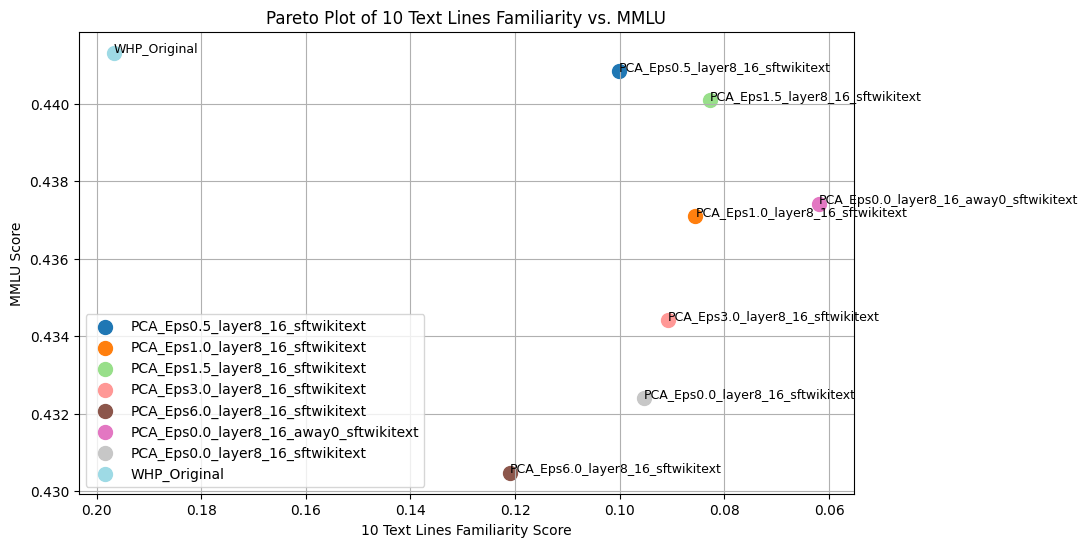

In [33]:
plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Text Lines', 2), ability_dict={name: accs["mmlu"] for name, accs in capability_dict.items()}, x_name="2 Text Lines Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Text Lines', 10), ability_dict={name: accs["mmlu"] for name, accs in capability_dict.items()}, x_name="10 Text Lines Familiarity", y_name="MMLU")



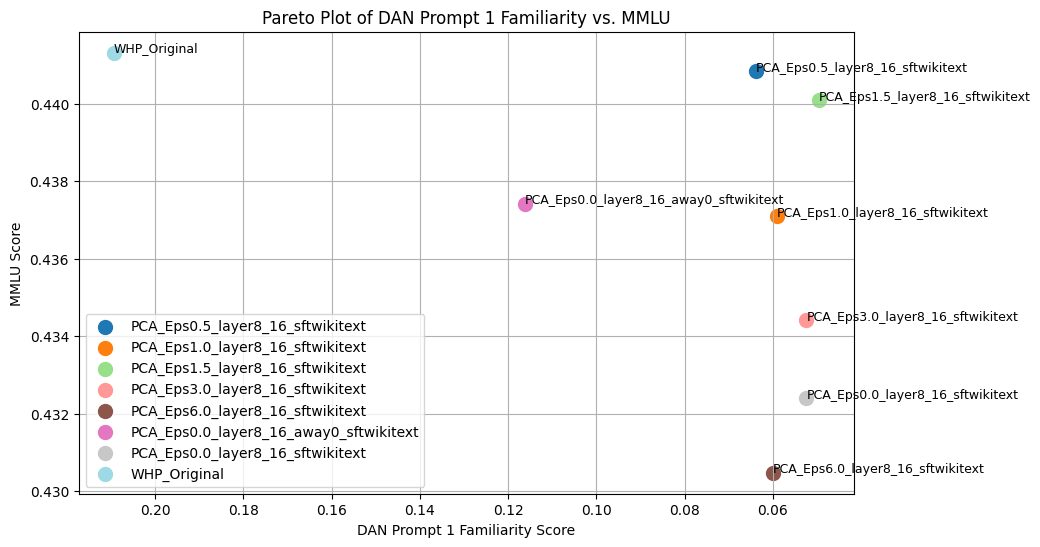

In [35]:
# plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'DAN Prompts', 0), ability_dict={name: accs["mmlu"] for name, accs in capability_dict.items()}, x_name="DAN Prompt 0 Familiarity", y_name="MMLU")

plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'DAN Prompts', 1), ability_dict={name: accs["mmlu"] for name, accs in capability_dict.items()}, x_name="DAN Prompt 1 Familiarity", y_name="MMLU")



In [ ]:
# plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'short'), ability_dict={name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Summary Style Familiarity", y_name="SciQ")

# plot_capability_pareto(familiarity_scores=get_fam_scores(df, 'Summary Style', 'long'), ability_dict={name: accs["sciq"]['acc,none'] for name, accs in capability_dict.items()}, x_name="Summary Style Familiarity", y_name="SciQ")